# Lab 068 · Drift-Resilient TabPFN: learn how relationships change

[Lesson](../lessons/0068-pfns-under-temporal-shift.html) · [Reference](../reference/0068-pfns-under-temporal-shift.html) · [Evidence](_verify_l068_v2_results.json) · [Reproduction](l068-reproduction.md)

**Built with TabPFN** · [License](sources/l068-v2/LICENSE.txt). Your goal is to implement five live operations and measure a future-domain comparison using every original checkpoint tensor. The model and generation algorithm are visible below. Default lab: full Electricity and original three-class Blobs datasets, first predeclared temporal cutoff, original base/drift checkpoint 1 and the separately pretrained NoT2V checkpoint 1. The author-reference table additionally covers Parking/Chess and three cutoffs/checkpoints. It is clearly separate from your current-kernel output. Downloads reuse seven original ~29 MB files as needed; default needs three. CPU is sufficient. Original pretraining and the optimized 18-task paper benchmark are NOT_RUN; this diagnostic is INCOMPARABLE to paper-result reproduction.

**Workflow:** retrieve and predict first, read the connected explanation, implement TODOs, run CHECKs, execute actual checkpoint predictions, and submit the EXIT JSON plus a written diagnosis. This notebook is self-contained; the following recap and figures do not require reopening the lesson.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## The task: extrapolate a learning problem

A sales conversion model trained through June may face a changed July relationship between lead activity and purchase. Holding out June rows estimates performance on the observed mixture. It does not establish whether the model can recognize a changing relationship and use its trend in July. For the relational mission, this distinction appears whenever customers, products, policies or measurements evolve. Even a point-in-time correct feature join can feed a prediction rule that has become stale.

**Your outcome:** trace how a temporal prior generates changing relationships; reconstruct the complete released Drift-Resilient TabPFN forward pass; and measure future-domain predictions with frozen historical contexts. You will implement five live operations, compare actual pretrained checkpoints, and explain a negative result without changing the evaluation after seeing it.

Before reading, retrieve three ideas in writing. What information may a query use in a PFN context? Why does a temporal split answer a different question from a random split? How can two predictors have identical accuracy but different log loss? The lab assumes matrix multiplication, sample standard deviation and softmax; each operation is restated below.

**Built with TabPFN.** Original weights and the visible re-expressed implementation use the [supplied license](sources/l068-v2/LICENSE.txt). Read Helli et al., [NeurIPS 2024, §§3–4 and Appendices A.4–A.8](https://papers.nips.cc/paper_files/paper/2024/file/b2e2774c8e76afe191b5bf518f5cb727-Paper-Conference.pdf), alongside the [pinned original implementation](https://github.com/automl/Drift-Resilient_TabPFN/tree/a6e75afb82d13e7abb46deade3669c4106b3d636). The full paper and appendices were audited. The release contains the evaluator, benchmark generators and seven real checkpoints; the original synthetic pretraining-prior generator was not found in that release.

## What shifts, and what is observed?

One row is `(x, y, c)`: a feature vector, class label and ordered domain index. A domain is a period or ordered group within which we approximate the data distribution as stable. Prediction receives source rows `(X_context, y_context, c_context)` and a new `(x_query, c_query)`. It does not receive future labels. The target is `p(y_query | x_query, c_query, context)`, with future domain indices beyond those observed in context.

| Shift | What changes | What remains fixed in this special case |
|---|---|---|
| Covariate | Distribution of X | P(Y given X) |
| Label or prior-probability | Class prevalence P(Y) | P(X given Y) |
| Concept | P(Y given X) | P(X) may remain fixed |

Here “prior-probability shift” concerns class prevalence, not the PFN’s prior over whole generating mechanisms. Real data can combine these changes. An edge change does not automatically identify the shift category after variables are hidden and marginalized.

For a simple concept shift, let `Y = 1[X1 + a(c) X2 > 0]`. If `a(c)` grows from zero to one while the feature distribution stays fixed, the decision boundary rotates. A historical mixture fit may place one compromise boundary through all periods. A temporal model may infer a trajectory and condition the boundary on the requested period. But two trajectories can agree on all observed domains and diverge tomorrow. Extrapolation requires an assumption; timestamp encoding does not make the future uniquely identifiable.

## The prior: a graph changes through another graph

An SCM, or structural causal model, generates variables through a directed acyclic graph. Each variable depends on its parents and sampled noise. The paper represents a causal variable by scalar subnodes, then expands parent-to-child assignments into hidden scalar computations. A causal relationship can therefore correspond to several functional edges, or neural weights.

The lab’s paper-grounded reconstruction has causal variables U, V, X and Y. U and V are noise roots. X has parents U and V; Y has parents U and X. X is computed through two hidden units:

`hX0 = tanh(w0 U + w2 V + ε2)`

`hX1 = tanh(w1 U + w3 V + ε3)`

`X = w4 hX0 + w5 hX1 + ε4`.

Y has two more hidden units using U and X, followed by its output. The target is `1[Y > 0]`; observed features are U, V and X. All eight scalar nodes are explicitly computed. Each of twelve functional edges has a source, destination and causal-relationship ID. This fixed declared topology is an inspectable expansion, not the paper’s unpublished graph-sampling distribution.

<div style="max-width:100%;overflow-x:auto" role="region" tabindex="0" aria-label="Scrollable computational figure"><img alt="Seed 2 paper-grounded reconstruction: one nonlinear second-order graph produces correlated edge trajectories. Only causal relations 0 and 3 shift; the shown relation-1 edge remains fixed. This is not the unavailable original pretraining sampler." src="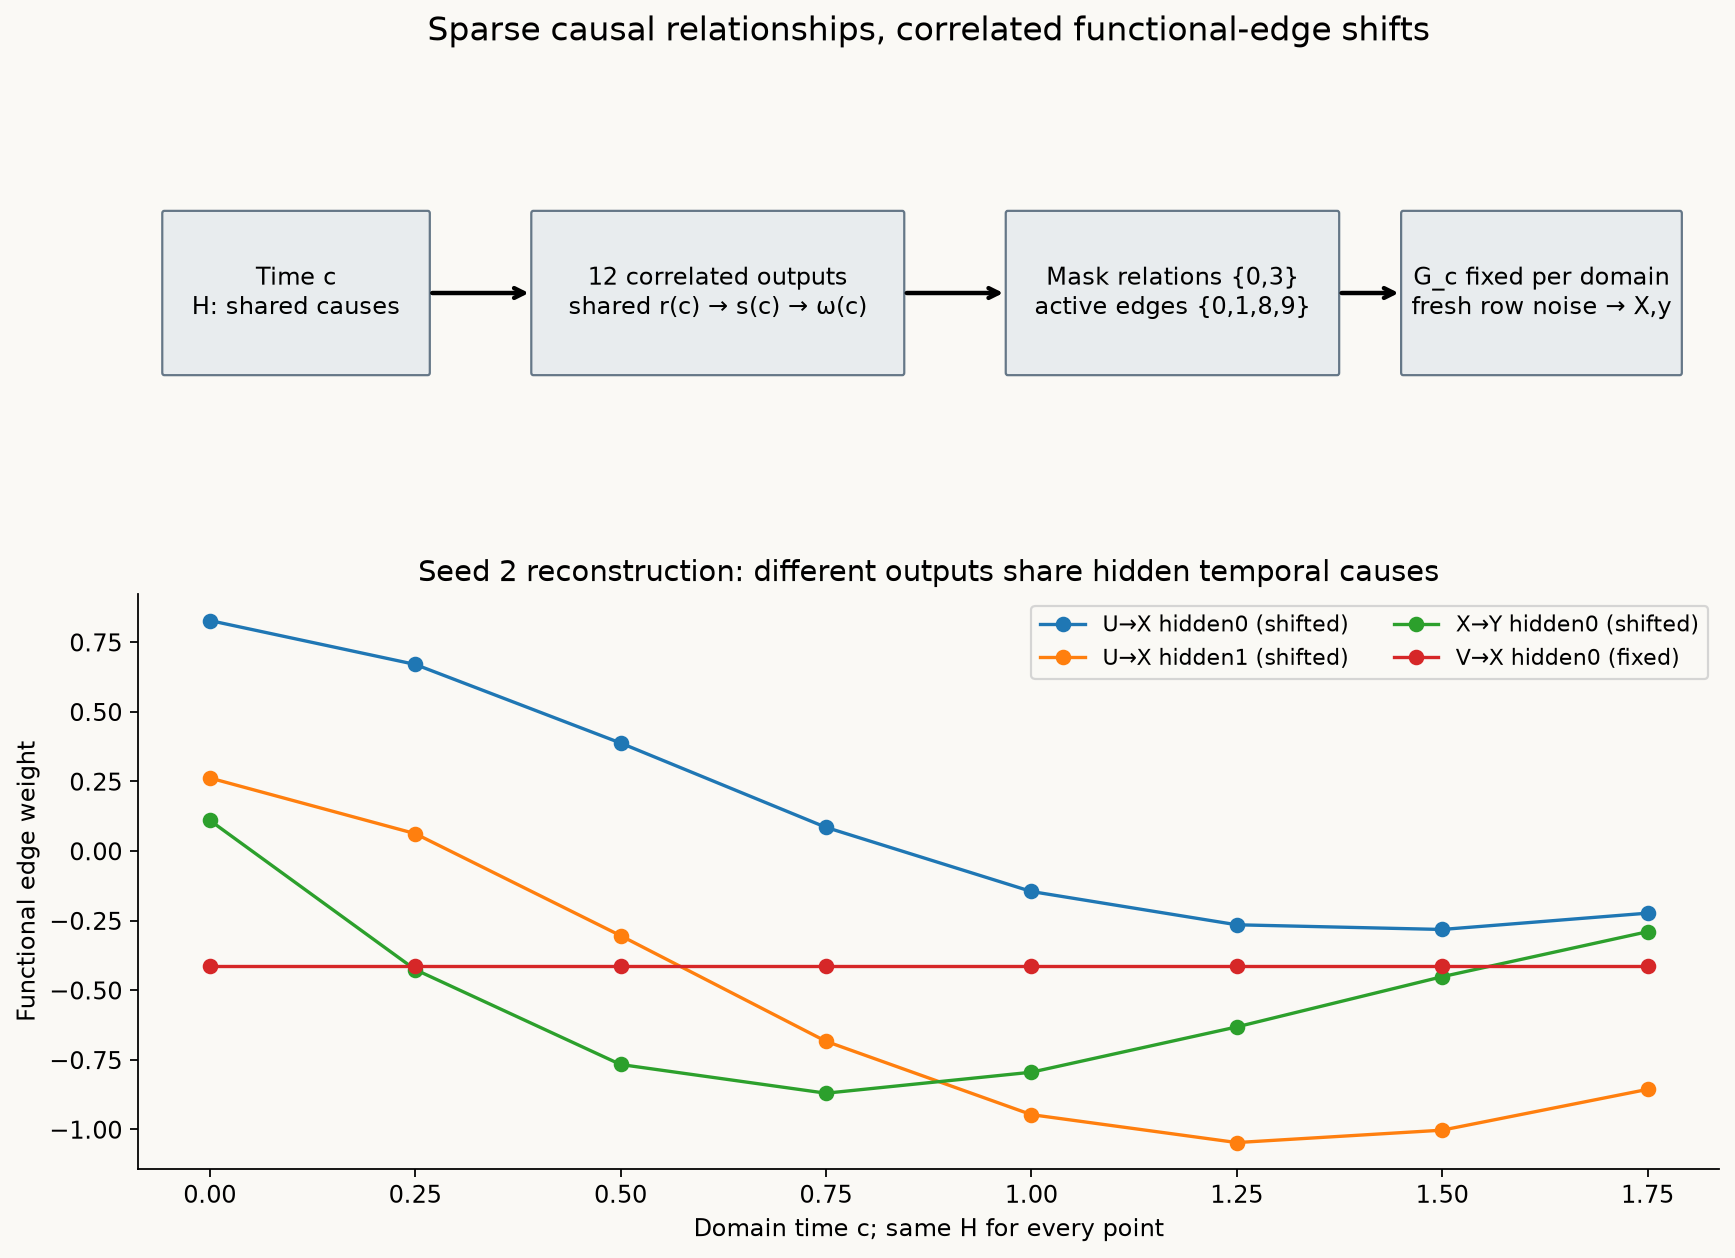" style="width:100%;min-width:900px;max-width:none;height:auto"></div>

Seed 2 paper-grounded reconstruction: one nonlinear second-order graph produces correlated edge trajectories. Only causal relations 0 and 3 shift; the shown relation-1 edge remains fixed. This is not the unavailable original pretraining sampler. [Full-size figure](figures/l068/scm-v2.png).

**Predict before tracing:** if only U→X and X→Y shift, may the V→X weights change? No. Selecting sparse relationships means applying a mask through the edge-to-relationship mapping. It does not mean sampling unrelated masks over arbitrary weight coordinates. Our relationship IDs `[0,0,1,1,-1,-1,2,2,3,3,-1,-1]` and selected IDs `[0,3]` activate only coordinates 0, 1, 8 and 9. The hidden-to-output edges marked −1 stay fixed in this reconstruction.

A second randomly generated nonlinear graph H receives time and emits a vector of shifts. In the visible reconstruction, time drives five shared hidden causes, then four nonlinear causes, then twelve outputs:

`r(c) = tanh(c A + b)`; `s(c) = sin(r(c) W)`; `ω(c) = 0.6 s(c) V`.

A, b, W and V are sampled once per generated dataset. They are not resampled independently at each time or row. Outputs share hidden causes, making temporal shifts correlated. The update is

`w_e(c) = w_e(base) + 1[relation(e) is selected] ω_e(c)`.

The additive update, activation choices, noise scale and topology above are explicit reconstruction choices. Algorithm 1 specifies a second-order SCM and a weight update; the release does not establish these exact hyperprior choices. We do not call this a reproduction of the original sampler.

A coherent numerical trace uses reconstruction seed 2. Base `w0 = 0.1891` becomes `0.8277` at domain-time 0 and `−0.1455` at domain-time 1. The V→X coefficient `w2 = −0.4131` remains fixed. In the first row at time 0, `U = 1.4285`, `V = −0.6676`, X’s hidden values are `0.9017, 0.9544`, and `X = 2.6814` after noise. Y’s hidden values are `−0.1612, 0.9475`; its continuous output is `−0.5573`, hence class 0. Values are rounded from the saved trace.

The timescales matter. H generates one weight vector per domain. G_c stays fixed while many rows receive fresh noise. Only after sampling the dataset do we create context/query tasks. Resampling H independently per row would remove the coherent changing mechanism that time is meant to identify. The lab saves H parameters, masks, node values, weight trajectories and actual checkpoint predictions for three reconstructed tasks. Its `shifted_weights` TODO changes the generated data and the measured predictions.

## Pretraining learns the inference rule

A PFN trains on many synthetic supervised tasks. Some labels become context inputs; held-out labels become targets. A schematic objective is

`E_task [ − Σ_query log q_θ(y_query | X_context, y_context, c_context, x_query, c_query) ]`.

The expectation covers graphs, mechanisms, time domains and row noise. Gradient descent changes transformer parameters θ. It does not optimize the sampled graph H: H generates tasks. With sufficient capacity and suitable optimization, this expected-loss training approximates posterior prediction under the chosen synthetic prior. That interpretation is conditional on the prior and approximation quality, not a correctness guarantee for a new real process.

The original base and drift models each processed 30,720,000 synthetic datasets over 30 pretraining epochs. The paper describes three retrainings and eight GPUs per pretraining job; Appendix A.3 reports roughly seven/eight days for the variants. These are offline development costs. At prediction time the learned weights stay fixed and in-context computation supplies predictions without gradient updates. This lab loads every tensor of those original checkpoints. Original pretraining is **NOT_RUN** here.

The main contribution is broader than adding time. A baseline with time can represent a temporal relationship, but its inference rule was pretrained on a different task distribution. Comparing base-with-time and drift-with-time tests the released packages under a matched wrapper. It does not isolate every pretraining choice individually.

## Time2Vec: preserve extrapolation, then encode the clock

The drift encoder rescales time using the source-context minimum and maximum. A query can map beyond [0,1]. Source times `[0,2,4]` and query time 6 give `τ = (6−0)/(4−0) = 1.5`. Including the query in range fitting would instead map it to 1, erasing its distance beyond the source endpoint. The source clips extreme normalized times to [−5,6], not [0,1].

If all source times equal 3, the source uses denominator 1: query time 4 maps to 1 and time 100 clips to 6. This avoids division by zero, but supplies no observed temporal trend. It is a degenerate case, not evidence of learning a trend from one period.

<div style="max-width:100%;overflow-x:auto" role="region" tabindex="0" aria-label="Scrollable computational figure"><img alt="Illustrative arithmetic, not actual checkpoint weights: source endpoints 0 and 4 map query 6 to 1.5; one linear and three sine channels give [1.5,0.7071,−1,0]. The actual model learns 100 time coordinates." src="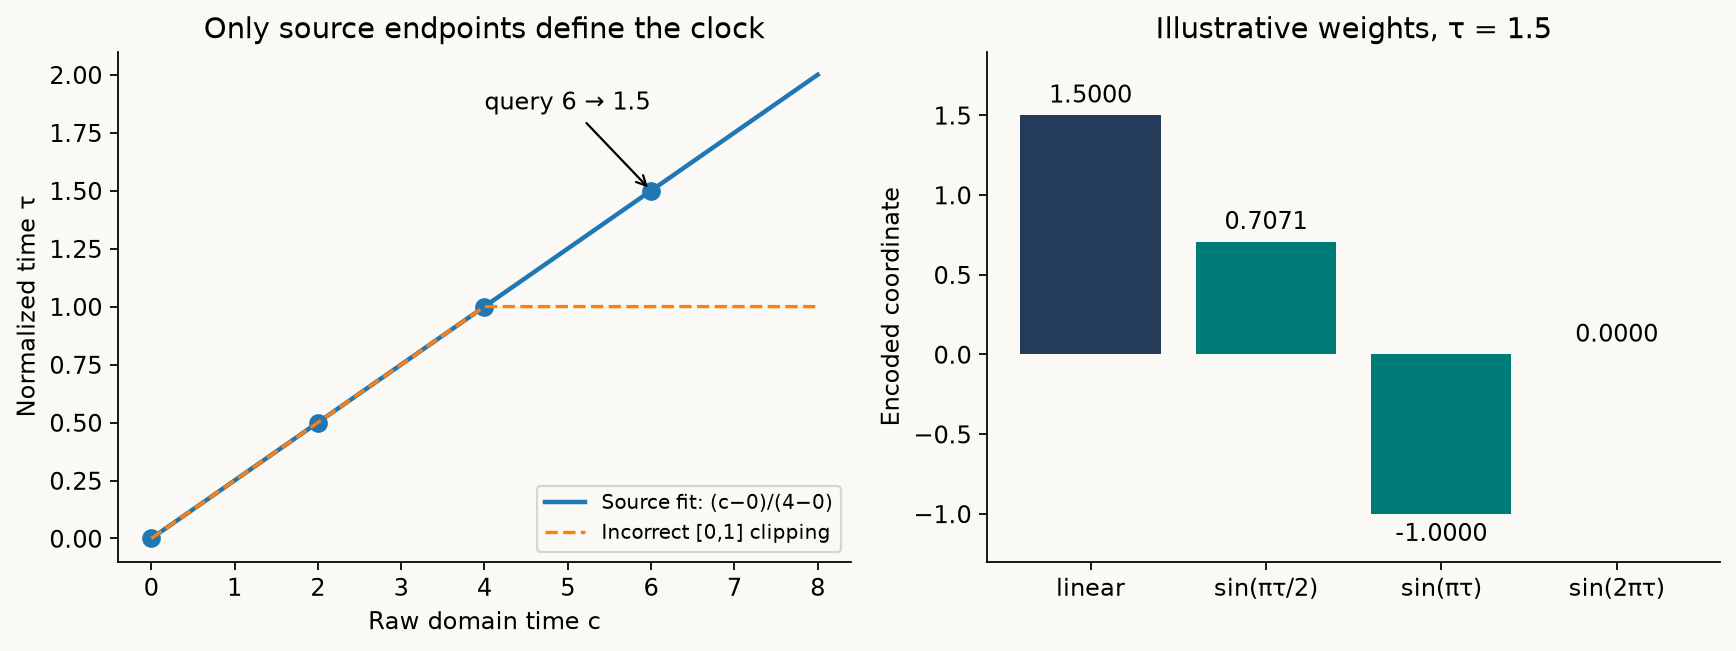" style="width:100%;min-width:800px;max-width:none;height:auto"></div>

Illustrative arithmetic, not actual checkpoint weights: source endpoints 0 and 4 map query 6 to 1.5; one linear and three sine channels give [1.5,0.7071,−1,0]. The actual model learns 100 time coordinates. [Full-size figure](figures/l068/time-v2.png).

Time2Vec applies a learned affine phase `a_j = ω_j τ + φ_j` to 100 coordinates. Coordinate 0 stays linear; coordinates 1–99 use sine. The linear channel can represent a trend; sinusoidal channels supply learned periods/phases. Neither guarantees seasonal stability. An illustrative four-coordinate encoding with weights `[1, π/2, π, 2π]` and zero phases maps τ=1.5 to `[1.5, 0.7071, −1, 0]`. These four weights teach arithmetic; the actual model uses all 100 learned coordinates.

The release repeats that 100-vector for every feature group and concatenates it with two numeric coordinates before a 102→192 projection. It does **not** make a separate time token. An original forward comment describes a separate token; the executed repetition/concatenation and the checkpoint’s 102-column weight matrix determine the implemented architecture.

## Model architecture: complete released checkpoint

<div style="max-width:100%;overflow-x:auto" role="region" tabindex="0" aria-label="Scrollable computational figure"><img alt="Complete released drift checkpoint: 12 alternating feature/row blocks, width 192, six heads, group size 2. Time is repeated within every feature group. Queries provide features/time and a censored target channel; the prediction head reads the query target token." src="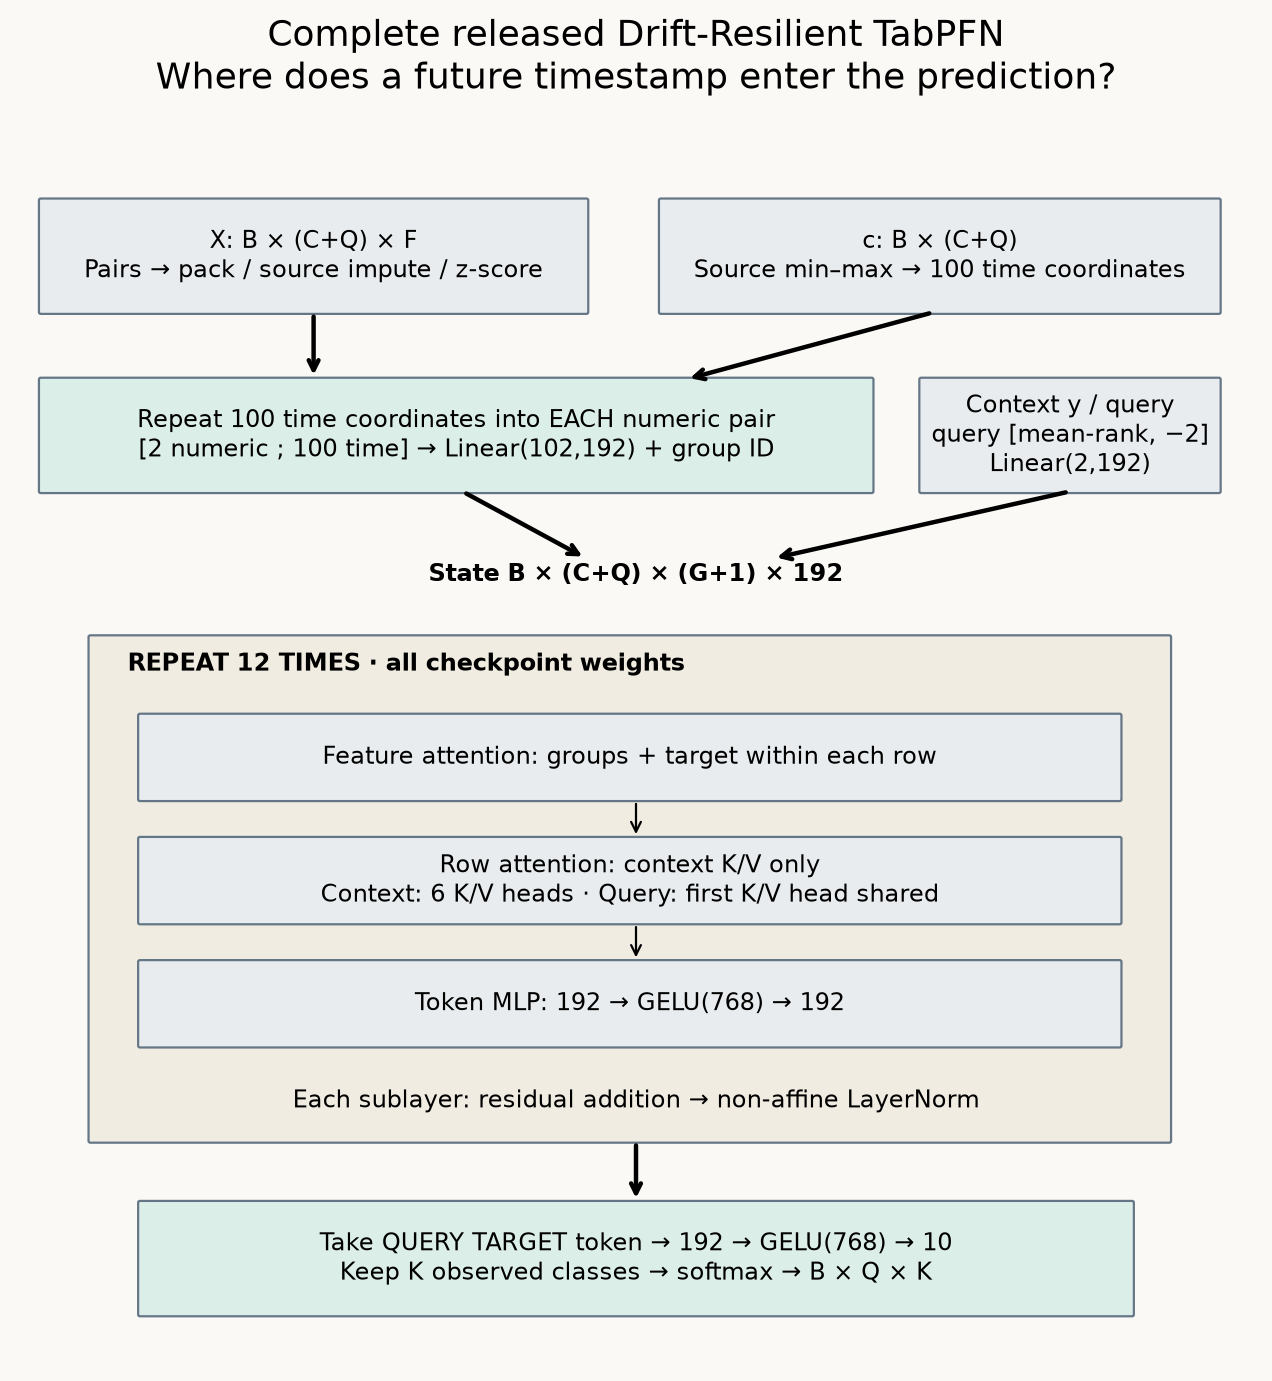" style="width:100%;min-width:900px;max-width:none;height:auto"></div>

Complete released drift checkpoint: 12 alternating feature/row blocks, width 192, six heads, group size 2. Time is repeated within every feature group. Queries provide features/time and a censored target channel; the prediction head reads the query target token. [Full-size figure](figures/l068/architecture-v2.png).

Let B count datasets in a batch, T=C+Q their rows, F their numeric columns, and G=ceil(F/2) their groups. C labels are provided; Q are withheld. Follow the whole computation:

1. **Group and normalize.** Pad F to an even number and group adjacent columns in pairs. Flatten groups into the batch axis for preprocessing. Pack varying coordinates first, impute missing values with source means, standardize with the source sample standard deviation plus `1e−6`, clip to ±100, and multiply by `sqrt(2 / active_coordinates)` before padding back to two. Numeric NaN flags are disabled in these checkpoints. Source constant/active-coordinate checks inspect all supplied rows despite training-only comments. Mean/variance fitting still uses context rows. We preserve and disclose that query-dependent edge case rather than silently changing it and claiming parity.
2. **Encode groups and time.** Drift concatenates 100 time coordinates and two numeric values, then projects 102→192 with bias. Separately pretrained NoT2V concatenates one normalized time coordinate and projects 3→192. Base projects 2→192. Add a group identity drawn as a 48-dimensional Gaussian vector and projected to 192 with checkpoint weights. Our wrapper resets a recorded nonzero seed before each call; raw original calls otherwise advance the generator.
3. **Encode labels.** Context classes are contiguous ordinal IDs. Query labels are censored, imputed for a value channel, and accompanied by missing flag −2. The ordinal encoder ranks values relative to observed classes. A query may therefore have value 1 and flag −2, distinguished from observed class 1 by its flag. A 2→192 projection makes one target token per row. Query targets are absent from the model’s forward signature.
4. **Repeat twelve blocks.** State shape is B×T×(G+1)×192. Six-head attention first mixes feature-group and target tokens within each row. Row attention then mixes rows separately at each token position. Source rows attend to source rows. Query rows use source keys/values only, sharing the first key/value head across six query heads; source attention keeps all six. A bias-free 192→768→192 GELU MLP follows. Every sublayer adds its residual before non-affine LayerNorm, epsilon `1e−5`.
5. **Read the query target.** Select Q target-token states; apply a biased 192→768→10 GELU head. Keep K observed-class logits and softmax. Softmax maps scores z to `exp(z_k)/Σ exp(z_j)`. Our matched wrapper uses temperature 1 for every arm.

Attention computes `softmax(Q Kᵀ / sqrt(32)) V`: a weighted average of value vectors. The head width is 192/6=32. The active original Torch ≥2 branch uses the exact inverse-square-root scale; the older fallback rounded that scalar. Our final operator matches the active branch. Query features enter their own row’s feature attention, but query rows never become memory keys. All twelve layers and every learned tensor are loaded, including time, group identity, label encoder and head. Full source checks compare input tokens, every block and logits across all three variants and both float32/float64 fixtures.

## Decide the experiment before opening results

The author panel uses exact released dataset preparation and full datasets: Electricity (1,260 rows, 5 features), Parking Birmingham (1,294, 4), Chess (533, 9), and Intersecting Blobs (1,680, 2). Every processed feature, label, domain and column name matches the original loader. Numeric category codes are retained. The first three are real data; Blobs is a separate synthetic mechanism probe.

Electricity uses weekly groups after every-fourth-half-hour selection and a fixed 15-week segment; the executed code uses one week despite a nearby two-week comment. Parking predicts occupancy quartile at one specified car park with week as its domain. Chess groups twenty sorted games to approximate progress; this clock compresses irregular elapsed time. Blobs has three moving classes over fourteen domains. Appendix A.7.2.1 calls it binary in one sentence but then describes three classes; the release and this lab use three. Age bins and house-build years in the broader paper roster are ordered proxies, not automatically deployment-time forecasting tasks.

<div style="max-width:100%;overflow-x:auto" role="region" tabindex="0" aria-label="Scrollable computational figure"><img alt="Actual Electricity row counts for three predeclared cutoffs. ID rows are withheld inside each source week; all OOD weeks share the frozen historical context. These are new deterministic cutoffs, not a replay of original random split selection." src="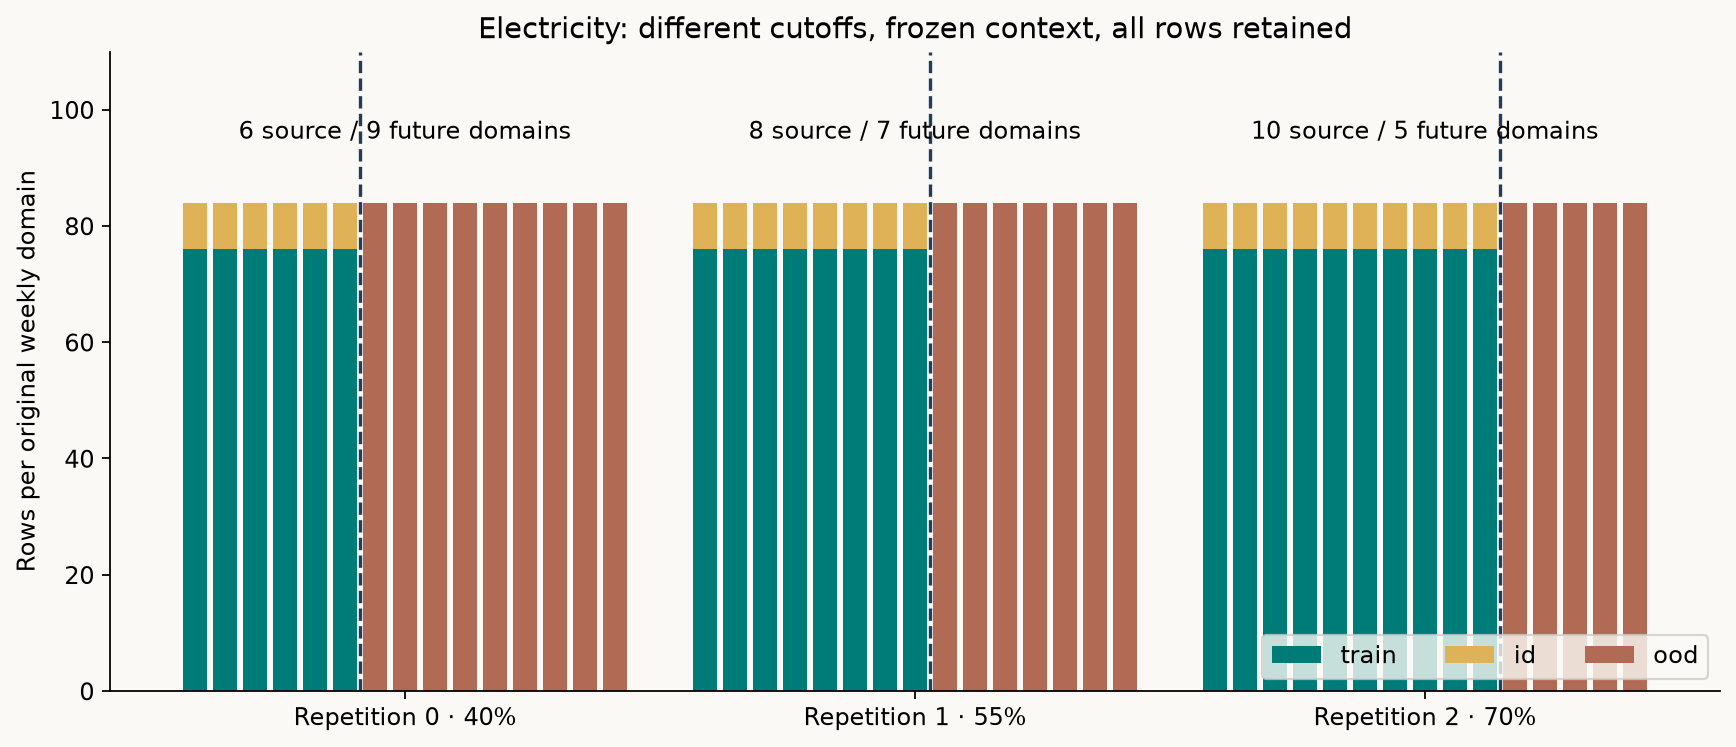" style="width:100%;min-width:800px;max-width:none;height:auto"></div>

Actual Electricity row counts for three predeclared cutoffs. ID rows are withheld inside each source week; all OOD weeks share the frozen historical context. These are new deterministic cutoffs, not a replay of original random split selection. [Full-size figure](figures/l068/split-v2.png).

We predeclare source fractions 0.40, 0.55 and 0.70 of ordered domains, rounded down to whole domains. Context stays frozen before each boundary. Ten percent of each source domain (floor, at least one) is held out as ID test. All remaining future domains are OOD test. Their labels never enter prediction calls. Seeds 0, 1, 2 choose source holdouts and pair with original base/drift checkpoints 1, 2, 3 and group-vector seeds 17, 18, 19. **All rows are retained** in the final panel. The capped and rounded-scale pilots retain separate evidence/operator identities.

These repetitions vary cutoff, holdout and pretrained initialization together. Sample SD describes those declared repetitions; it neither separates variance components nor estimates uncertainty across independent datasets. Only NoT2V checkpoint 1 is released, so it is reused. Some ID slices lack a class: accuracy and log loss remain defined, but full-class AUC is unavailable. We do not retry labels into a more convenient ID sample.

| Arm | Context/data | Learned package | Question |
|---|---|---|---|
| base_no_time | Historical context, no time | Original base checkpoint | Historical mixture baseline |
| base_time | Same context, time appended | Same base checkpoint | Does ordinary time access help? |
| drift | Same context, separate domain input | Original drift checkpoint | Does the temporal package help? |
| drift_zero | Same features, all times zero | Same drift checkpoint | Sensitivity to clock information? |
| noT2V | Same context, normalized scalar time | Separately pretrained checkpoint 1 | Available training ablation behavior? |

Zero-time still passes through learned Time2Vec biases. It is not the paper’s NoT2V training ablation. Base-with-time changes feature grouping, as the original baseline strategy does; it is a package contrast, not a surgical prior-only intervention.

The paper uses three random eligible cutoffs, with 30–80% of **both domains and samples** in the source portion, class-coverage checks/retries, and three model initializations per split. Our deterministic fractions do not claim that full selection contract or factorial replication. Original preprocessing was selected on twelve validation datasets. The released `best_dist` uses robust preprocessing plus original features, fingerprints, 32 feature/class-shuffled views, 99% sample subsampling, outlier setting 7, temperature 0.9 and fp16. `best_base` uses a different selected recipe and temperature 0.75. Our raw numeric, one-view, fp32, temperature-1 comparison has no preprocessing search or class retries: **INCOMPARABLE to reproducing paper Tables 1/2 or Figure 5**.

## What the published experiment establishes

The paper’s **published means** are separate from every local number below. On eight synthetic tasks, Table 1 reports OOD accuracy 0.754 for drift versus the strongest baseline 0.665. On ten real tasks those means are 0.736 versus 0.712. The real-data AUC difference is much smaller: 0.822 versus the strongest baseline 0.820. Stronger synthetic improvements do not establish a comparably large real-data advantage.

Table 2 compares drift with the separately pretrained NoT2V ablation: OOD accuracy 0.744 versus 0.742 and AUC 0.832 for both. The authors describe the Time2Vec contribution as statistically insignificant; this is why the lesson emphasizes the shifting prior. These results use the original selected recipes and repetitions. “Strongest baseline” can select different packages for different metrics, so this summary is not a pure prior-only causal intervention. See [Tables 1–2 and Appendix A.4.1](https://arxiv.org/html/2411.10634v1#A1.SS4.SSS1) for the reported uncertainty and exact comparator settings.

## Read measured probabilities, not just winners

Before revealing results, predict whether drift must beat base-with-time on every real task, and whether confidence must fall monotonically into the future. Commit a direction and reason. The mechanism allows exceptions to both claims.

### Author-reference evidence · not current-kernel output

| Dataset | Arm | OOD accuracy ± SD | OOD AUC ± SD | OOD log loss ± SD |
|---|---|---:|---:|---:|
| blobs | base_no_time | 0.4910 ± 0.0868 | 0.6398 ± 0.0158 | 3.1463 ± 1.0432 |
| blobs | base_time | 0.5961 ± 0.2934 | 0.7758 ± 0.1988 | 1.1951 ± 0.7433 |
| blobs | drift | 0.9487 ± 0.0406 | 0.9965 ± 0.0058 | 0.2019 ± 0.0714 |
| blobs | drift_zero | 0.4448 ± 0.0961 | 0.6241 ± 0.0787 | 2.8558 ± 0.6079 |
| blobs | noT2V | 0.9908 ± 0.0026 | 0.9998 ± 0.0001 | 0.1573 ± 0.1091 |
| chess | base_no_time | 0.7197 ± 0.0115 | 0.7860 ± 0.0306 | 0.6947 ± 0.0214 |
| chess | base_time | 0.7158 ± 0.0360 | 0.7872 ± 0.0337 | 0.7033 ± 0.0294 |
| chess | drift | 0.6762 ± 0.0540 | 0.7577 ± 0.0346 | 0.7721 ± 0.0537 |
| chess | drift_zero | 0.6947 ± 0.0146 | 0.7872 ± 0.0313 | 0.7101 ± 0.0330 |
| chess | noT2V | 0.6483 ± 0.0535 | 0.6358 ± 0.2443 | 0.8016 ± 0.1218 |
| electricity | base_no_time | 0.6435 ± 0.0573 | 0.7730 ± 0.0451 | 0.6979 ± 0.0882 |
| electricity | base_time | 0.6456 ± 0.1547 | 0.7492 ± 0.0541 | 0.6135 ± 0.1161 |
| electricity | drift | 0.6616 ± 0.0480 | 0.7467 ± 0.0602 | 0.6096 ± 0.0550 |
| electricity | drift_zero | 0.6343 ± 0.0086 | 0.7625 ± 0.0148 | 0.6843 ± 0.0047 |
| electricity | noT2V | 0.6773 ± 0.0577 | 0.7403 ± 0.0763 | 0.5924 ± 0.0595 |
| parking | base_no_time | 0.4725 ± 0.1848 | 0.8012 ± 0.0429 | 1.0072 ± 0.1754 |
| parking | base_time | 0.5101 ± 0.0589 | 0.8327 ± 0.0208 | 1.0233 ± 0.0675 |
| parking | drift | 0.6644 ± 0.0559 | 0.8496 ± 0.0255 | 0.8757 ± 0.0961 |
| parking | drift_zero | 0.6866 ± 0.0170 | 0.8653 ± 0.0175 | 0.8521 ± 0.0908 |
| parking | noT2V | 0.7119 ± 0.0336 | 0.8507 ± 0.0253 | 0.8686 ± 0.0702 |

The complete-model panel is mixed on real data. On Chess, drift worsens mean OOD accuracy from base-with-time 0.7158 to 0.6762 and log loss from 0.7033 to 0.7721. On Parking it raises accuracy from 0.5101 to 0.6644 and lowers loss from 1.0233 to 0.8757, but zeroing time improves the drift checkpoint further (accuracy 0.6866, loss 0.8521): clock sensitivity is not uniformly beneficial. Electricity illustrates metric disagreement: drift slightly improves accuracy (0.6456 to 0.6616) and log loss (0.6135 to 0.6096), while AUC falls from 0.7492 to 0.7467. Blobs is much stronger evidence for extrapolating this synthetic mechanism: drift accuracy 0.9487 versus base-with-time 0.5961; zero-time falls to 0.4448. The separately pretrained NoT2V checkpoint reaches 0.9908 on Blobs, supporting the distinction between the temporal prior and Time2Vec without isolating pretraining variance. These are local matched-wrapper results, not the paper benchmark. Across three real datasets the mean drift-minus-base-time log-loss gap is -0.0276, with a coarse dataset-bootstrap 95% percentile interval [-0.1476, 0.0688]. Three datasets cannot support a broad superiority conclusion; the bootstrap cannot invent unseen tasks.

<div style="max-width:100%;overflow-x:auto" role="region" tabindex="0" aria-label="Scrollable computational figure"><img alt="Fresh full-model OOD log loss on three real tasks and the released synthetic Blobs task. Dots are joint cutoff/checkpoint repetitions; bars are sample SD, not independent-dataset confidence intervals." src="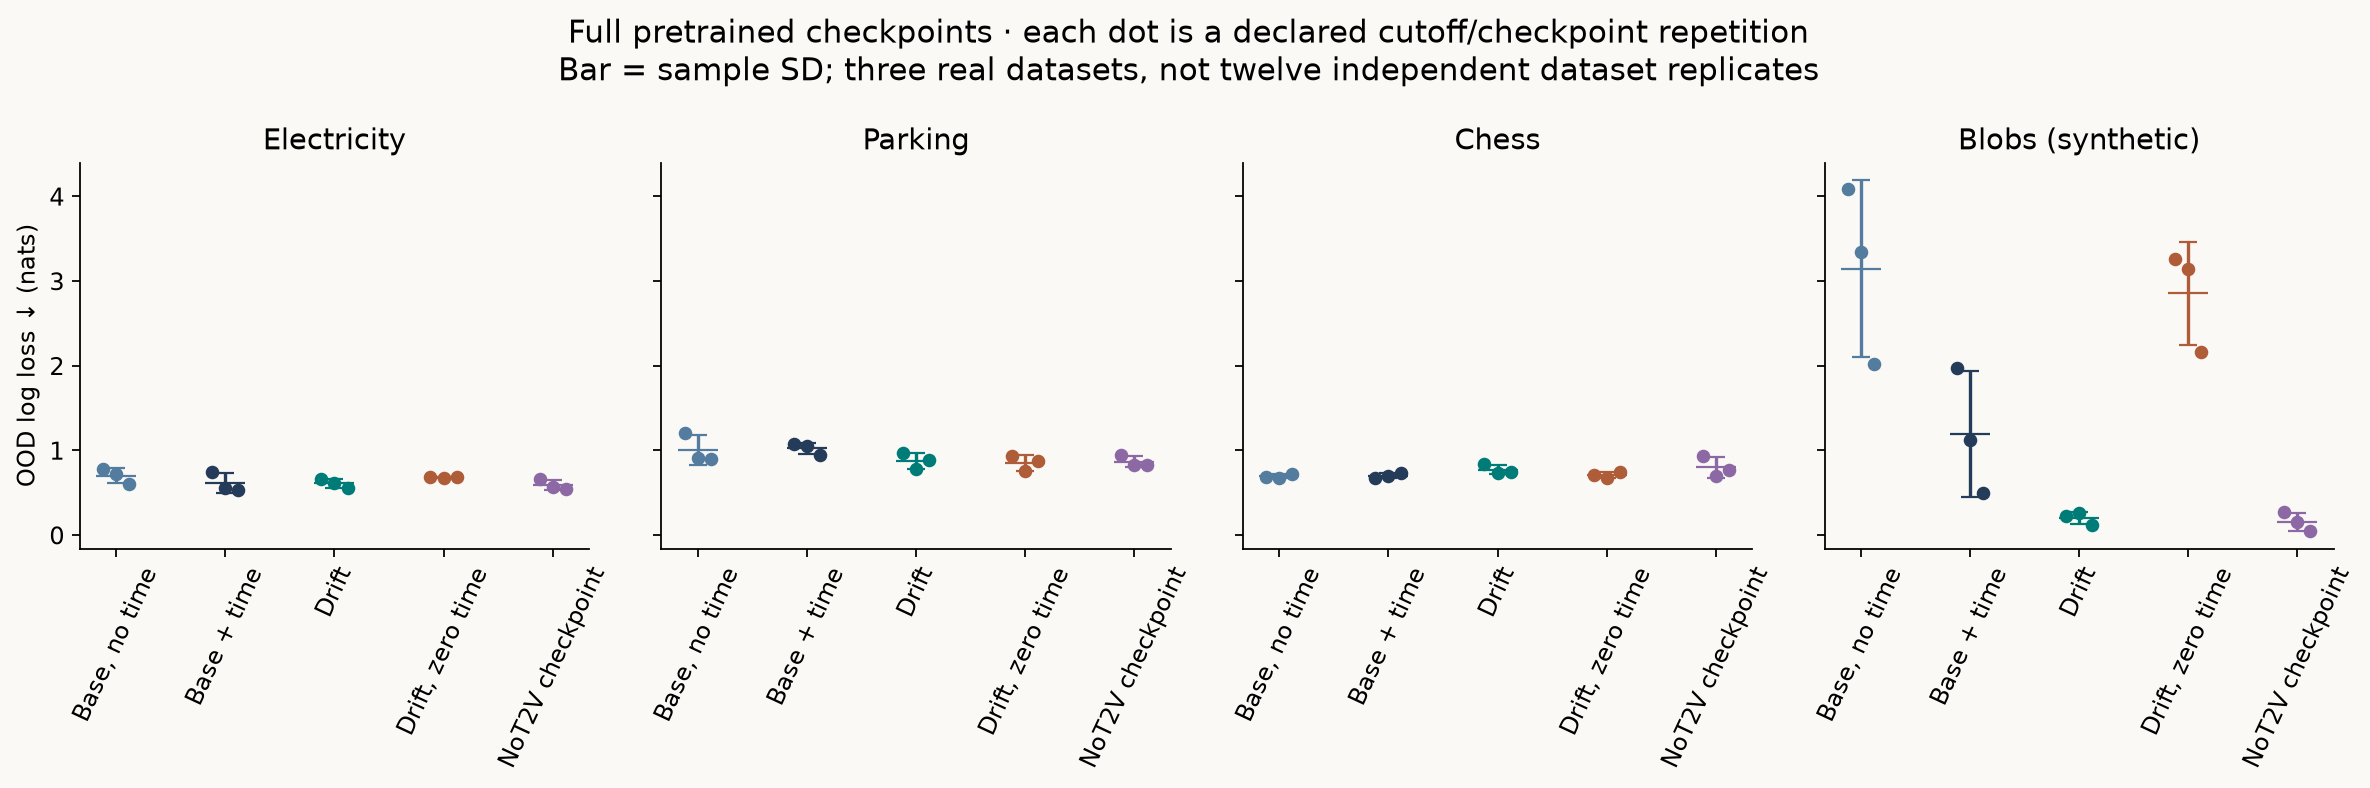" style="width:100%;min-width:1150px;max-width:none;height:auto"></div>

Fresh full-model OOD log loss on three real tasks and the released synthetic Blobs task. Dots are joint cutoff/checkpoint repetitions; bars are sample SD, not independent-dataset confidence intervals. [Full-size figure](figures/l068/results-v2.png).

Accuracy is the fraction whose highest-probability class is correct. AUC measures class-score ranking; multiclass AUC averages one-versus-rest class AUCs when every class is present. Log loss averages `−log(probability of the true class)`, penalizing confident wrong predictions. Giving the true class 0.9 costs 0.105 nats; giving it 0.1 costs 2.303. Accuracy cannot distinguish a wrong 0.51/0.49 decision from a wrong 0.99/0.01 decision.

<div style="max-width:100%;overflow-x:auto" role="region" tabindex="0" aria-label="Scrollable computational figure"><img alt="Actual per-domain OOD losses in repetition 0. Every line retains one historical context and checkpoint. Domain difficulty varies; adjacent points are not independent datasets." src="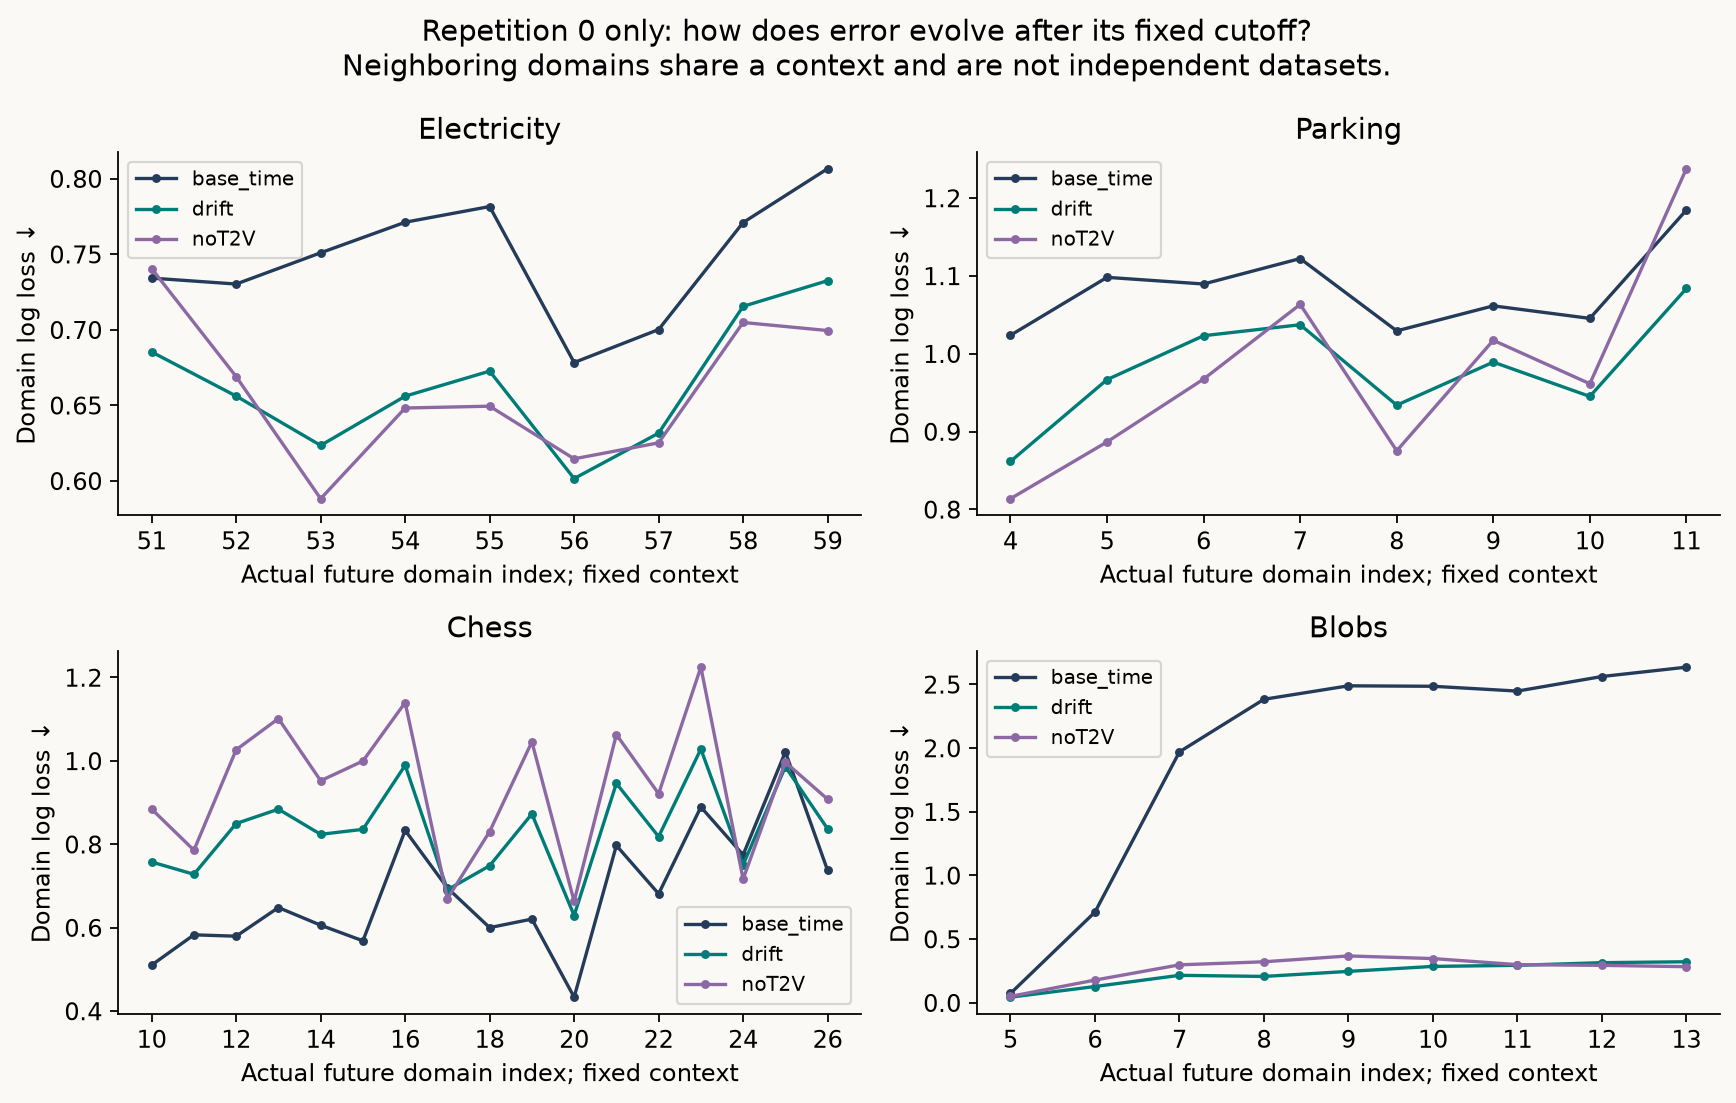" style="width:100%;min-width:900px;max-width:none;height:auto"></div>

Actual per-domain OOD losses in repetition 0. Every line retains one historical context and checkpoint. Domain difficulty varies; adjacent points are not independent datasets. [Full-size figure](figures/l068/horizon-v2.png).

The horizon plots hold repetition 0’s context and checkpoint fixed. Each point scores only one future domain. Error need not grow smoothly: domains differ in prevalence and difficulty, and sample sizes are finite. These points diagnose where the model helps or fails; they are not independent dataset replications.

<div style="max-width:100%;overflow-x:auto" role="region" tabindex="0" aria-label="Scrollable computational figure"><img alt="Original Blobs source, domains 0–3 as fixed context, checkpoint 1; actual predictions on a 36×36 query grid. Panels vary requested future domain only. Background is predicted class, points are class-labeled observations; optimized paper Figure 5 was not reproduced." src="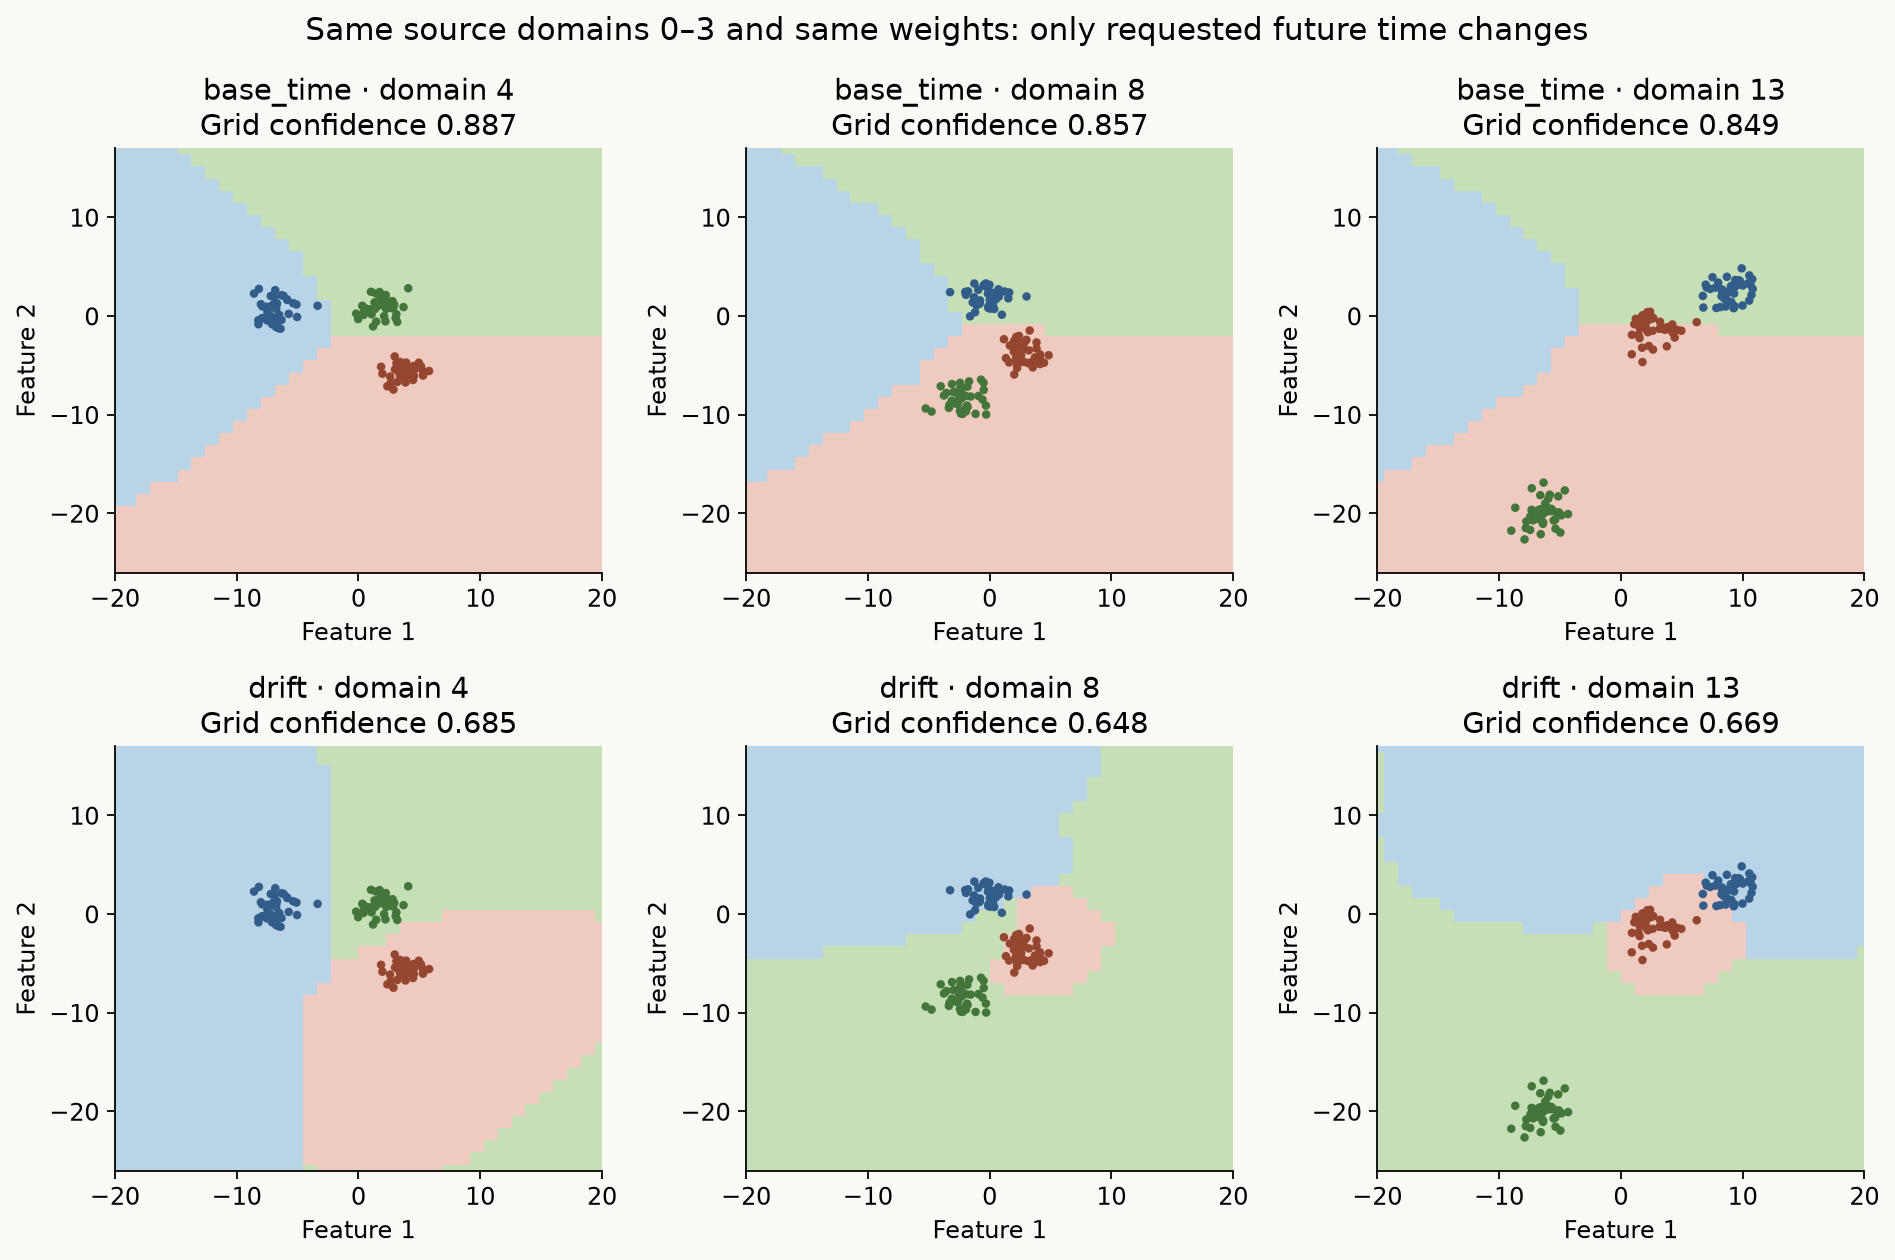" style="width:100%;min-width:1150px;max-width:none;height:auto"></div>

Original Blobs source, domains 0–3 as fixed context, checkpoint 1; actual predictions on a 36×36 query grid. Panels vary requested future domain only. Background is predicted class, points are class-labeled observations; optimized paper Figure 5 was not reproduced. [Full-size figure](figures/l068/boundary-v2.png).

The boundary figure uses original Blobs data, fixed source domains 0–3, checkpoint 1 and a fixed 36×36 grid at domains 4, 8 and 13. Colors encode predicted class. Weights never change between panels. A changed boundary comes from conditioned inference, not later labels or gradient steps. The matched wrapper differs from published Figure 5: this is fresh evidence, not a reproduction claim.

On the fixed grid, drift mean maximum-class confidence is approximately 0.685, 0.648 and 0.669. It is lower than the corresponding base values but rises again at the last horizon. This contradicts a universal claim that uncertainty always grows with elapsed time. It is not a calibration measurement: grid points form an artificial spatial measure, and calibration needs outcomes under a defined distribution.

<div style="max-width:100%;overflow-x:auto" role="region" tabindex="0" aria-label="Scrollable computational figure"><img alt="Average repetitions within each real dataset, rank arms, then average three dataset ranks. Exploratory Friedman/Nemenyi checks show no resolved pairwise difference; this neither proves equivalence nor reproduces the paper’s Wilcoxon-Holm diagram." src="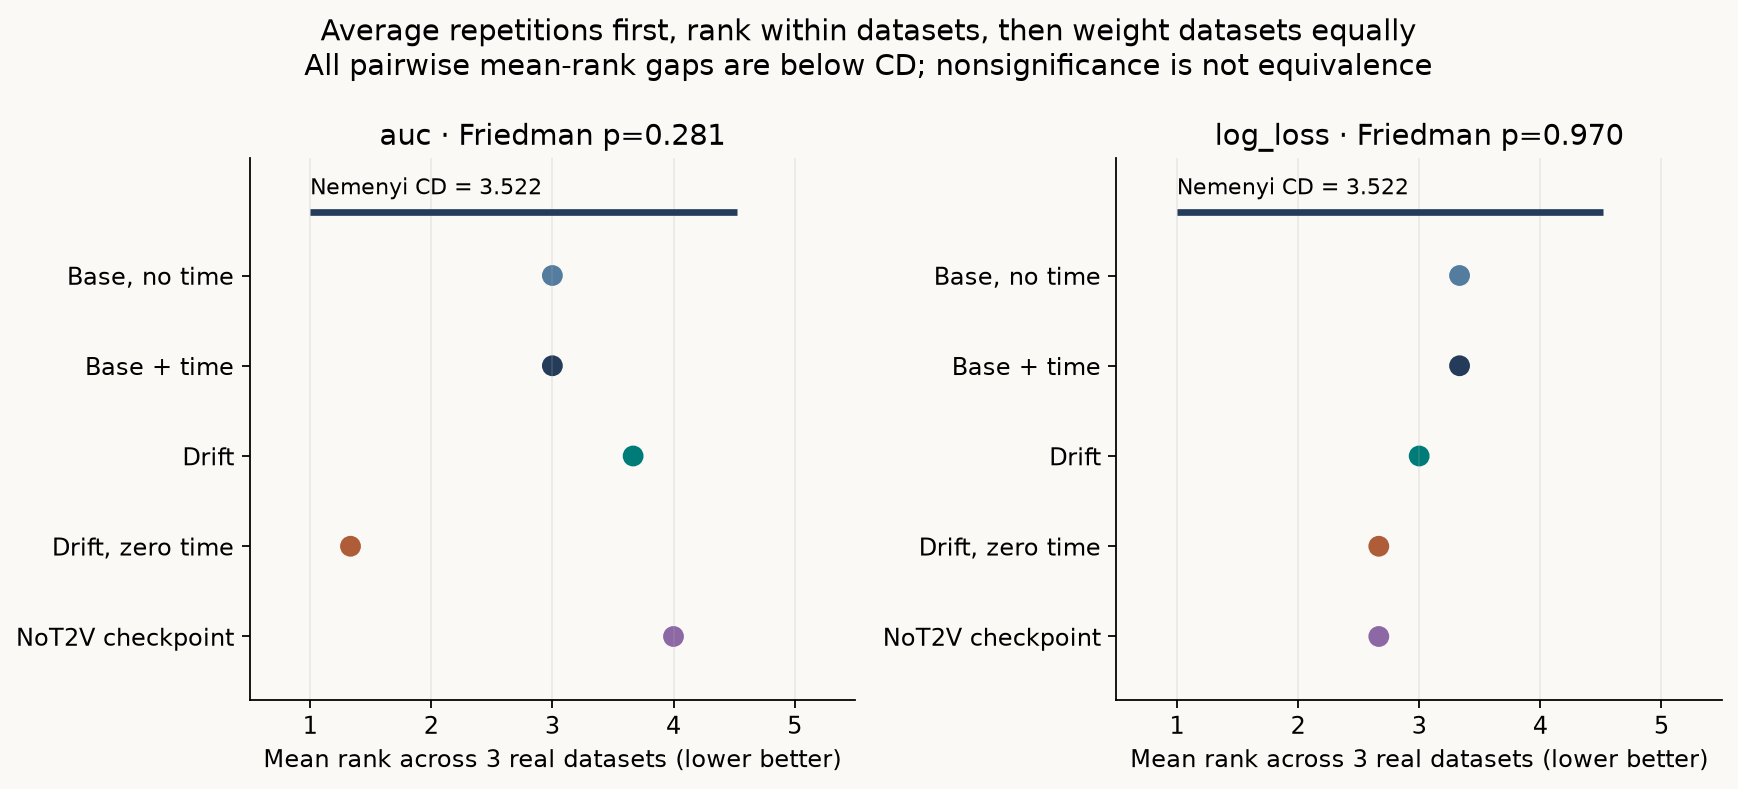" style="width:100%;min-width:800px;max-width:none;height:auto"></div>

Average repetitions within each real dataset, rank arms, then average three dataset ranks. Exploratory Friedman/Nemenyi checks show no resolved pairwise difference; this neither proves equivalence nor reproduces the paper’s Wilcoxon-Holm diagram. [Full-size figure](figures/l068/ranks-v2.png).

Average repetitions within each dataset, then rank methods within that dataset. The real-task aggregate weights Electricity, Parking and Chess equally; Blobs is separate. The displayed Friedman/Nemenyi calculation is exploratory on only three datasets. The paper’s Figure 10 instead uses Wilcoxon-Holm comparisons on its larger benchmark. Rows, seeds and domains cannot become extra independent datasets to manufacture narrower uncertainty.

## Diagnose a failure and design the next experiment

Find the earliest changed computation. Wrong query time suggests context-plus-query range fitting or [0,1] clipping. Wrong input tokens with correct numeric z-scores suggest packing, concatenation, target censoring or group-RNG state. Correct input followed by a first-block discrepancy suggests attention axes, first-head query K/V sharing, scaling, or pre-norm versus post-norm. Correct logits with changed scores suggests temperature, class axis, row IDs or metric definitions.

Source correspondence covers the tested path. It does not establish exact historical library execution, original prior sampling/training, optimized 32-view inference, or paper-score reproduction. The [reproduction contract](l068-reproduction.md) provides executable smoke, full local and broader routes with precise remaining paper work. Original and live notebook identities stay separate; EXIT records the actual current implementation and run.

Lesson 064 exposed alternating feature/row attention, while Lesson 066 used a column→row→in-context prediction pipeline. This released temporal model also uses a two-axis transformer, but its new assumption comes from changing task mechanisms and a domain-conditioned encoding. Efficient representation and reliable drift extrapolation answer different questions; sharing an attention pattern does not confer the latter.

LoCalPFN chooses a local context and fine-tunes model weights. This model learns a temporal inductive bias during pretraining, then holds weights and historical context fixed while conditioning on the requested domain. Combining them may help, but nearest-neighbor selection may also erase older domains needed to infer a trend. A useful next experiment varies history length at a fixed prediction horizon, with the same checkpoint and test rows, before adding adaptation.

**Teach back:** explain why H generates a prior rather than acting as the deployed forecaster; why a relationship mask differs from one arbitrary edge; why normalized query time 1.5 is legitimate; and why zero-time sensitivity differs from NoT2V pretraining. Use one actual negative real-task result and the nonmonotonic confidence trace to limit your conclusion. Bring EXIT and your explanation to the tutor; notebook completion alone is not mastery evidence.

## PROVIDED · The live implementation begins here

Definitions below execute in your namespace. Model construction, all checkpoint loading, every prediction, the sparse prior diagnostic and summaries call these functions. The independent original implementation is used only to verify correspondence. The original data-loader functions retain attribution and are adapted only to the local collector/path interface.

In [ ]:
# PROVIDED — runtime imports and a fresh destination
import copy,hashlib,importlib.metadata,inspect,json,math,os,time,types,sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.metrics import log_loss,roc_auc_score,accuracy_score
from IPython.display import display
for directory in [Path.cwd(),Path.cwd()/'labs',Path.cwd().parent]:
    if (directory/'relkit').is_dir():ROOT=directory.resolve();sys.path.insert(0,str(ROOT));break
else:raise RuntimeError('Run bootstrap or start Jupyter in labs')
torch.set_num_threads(1)
output=Path(os.environ.get('L068_OUTPUT',str(ROOT/'data/cache/l068-student')))
output.mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED — immutable source/data/model contracts
COMMIT='a6e75afb82d13e7abb46deade3669c4106b3d636'
BASE_URL='https://raw.githubusercontent.com/automl/Drift-Resilient_TabPFN/a6e75afb82d13e7abb46deade3669c4106b3d636/'
MODEL_CONFIG={'width': 192, 'heads': 6, 'hidden': 768, 'layers': 12, 'classes': 10, 'group_size': 2}
CHECKPOINTS={'tabpfn_base_model_2.cpkt': '9ff97d94eae134d708fcd4450e6dd13a2acabcf1b63219e8efc0e087f62fdaa0', 'tabpfn_base_model_1.cpkt': 'fc867cd7da84c7db813f3d68f0aa9f34dec9121d364d6c6c7140063499c1f892', 'tabpfn_base_model_3.cpkt': '0059a69b968e58439ee45b6863c9ce7a03d4019ac120dbfb6c430c767f72ec79', 'tabpfn_dist_ablation_no_t2v_model_1.cpkt': '8882a6d7000e76b7d6bf340492c914204407069240da406e8ebb22b18878375d', 'tabpfn_dist_model_1.cpkt': 'e653d21bd9b2713cf857696f98aabb2a59a4009212d1a63744feccbca94462db', 'tabpfn_dist_model_3.cpkt': 'a9ac82e89b2636999d0d1d7b8da9f7c8dff046ed7921339eec02f804cad369dc', 'tabpfn_dist_model_2.cpkt': '6020bfb897d1ac442aaa8f7ef90985e99740f240b714e79625e33cb205ba0c83'}
PROTOCOL={'source_fractions': [0.4, 0.55, 0.7], 'id_fraction': 0.1, 'temperature': 1.0, 'views': 1, 'raw_numeric': True, 'optimized_preprocessing': False, 'fp16': False, 'query_batching': False, 'pretraining': 'NOT_RUN', 'paper_reproduction': 'INCOMPARABLE'}
PRESETS68={'smoke': {'datasets': ['blobs'], 'seeds': [0], 'checkpoints': [1], 'cap_per_domain': 12}, 'lab': {'datasets': ['electricity', 'blobs'], 'seeds': [0], 'checkpoints': [1], 'cap_per_domain': None}, 'closer': {'datasets': ['electricity', 'parking', 'chess', 'blobs'], 'seeds': [0, 1, 2], 'checkpoints': [1, 2, 3], 'cap_per_domain': 64}, 'full_local': {'datasets': ['electricity', 'parking', 'chess', 'blobs'], 'seeds': [0, 1, 2], 'checkpoints': [1, 2, 3], 'cap_per_domain': None}}
DATA_SHA={'elec2.csv': 'e5406c893fe6c727729e1bdb09238424808b0e37e172b3a90aa18ed11dd79d17', 'parking_birmingham.csv': 'f1e28b9c697769a1a05cd20148241b60b1a73fee4907611163efc6fd9d12770a', 'chess.csv': 'c5f2fcaa52a351275223432cef0aa3117b9c8b9a6d5a69a03bf5a91cc88346ab'}
TASK_TYPE_MULTICLASS='multiclass'

## TODO 1 · Preserve future time

**Goal:** Map T×B×1 times using only the first n context rows, including constant contexts and the source clipping bounds.

**Why:** Fitting on future endpoints changes what extrapolation means.

**Hint:** Check where a query beyond the source maximum lands; handle a zero range without destroying offsets.

In [ ]:
# TODO — normalize_time
def normalize_time(c,n):
    raise NotImplementedError("Implement this live operation")

In [ ]:
# CHECK — normalize_time
c=torch.tensor([0.,2.,4.,6.,40.])[:,None,None]
torch.testing.assert_close(normalize_time(c,3).flatten(),torch.tensor([0.,.5,1.,1.5,6.]))
torch.testing.assert_close(normalize_time(torch.tensor([3.,3.,4.,100.])[:,None,None],2).flatten(),torch.tensor([0.,0.,1.,6.]))
assert normalize_time(c,3)[3]>1,'Do not clip ordinary extrapolation to1'
print("CHECK passed: normalize_time")

## TODO 2 · Encode trend and periodic phase

**Goal:** Apply all learned affine phases and the correct activation to each coordinate.

**Why:** The first coordinate and remaining 99 play different roles in every feature group.

**Hint:** Keep the first output linear; preserve arbitrary leading dimensions.

In [ ]:
# TODO — time2vec
def time2vec(c,weight,bias):
    raise NotImplementedError("Implement this live operation")

In [ ]:
# CHECK — time2vec
c=torch.tensor([1.5])[:,None,None];w=torch.tensor([[1.],[math.pi/2],[math.pi],[2*math.pi]]);b=torch.zeros(4)
torch.testing.assert_close(time2vec(c,w,b).flatten(),torch.tensor([1.5,2**-.5,-1.,0.]),atol=1e-6,rtol=0)
assert time2vec(torch.zeros_like(c),w,torch.tensor([2.,1.,0.,0.]))[0,0,0]==2,'Affine bias is part of the encoding'
print("CHECK passed: time2vec")

## TODO 3 · Shift relationships, not arbitrary edges

**Goal:** Return time-dependent functional weights using the causal-relation mapping and H outputs.

**Why:** This live function generates the measured SCM features and labels; sparse causal selection can activate several weights.

**Hint:** A relationship identifier can occur multiple times; fixed edges must retain their base weights at every time.

In [ ]:
# TODO — shifted_weights
def shifted_weights(base,edge_to_relation,selected,shifts):
    raise NotImplementedError("Implement this live operation")

In [ ]:
# CHECK — shifted_weights
base=np.array([1.,2.,3.,4.]);mapping=np.array([0,0,1,-1]);shifts=np.array([[.1,.2,.3,.4],[.5,.6,.7,.8]])
np.testing.assert_allclose(shifted_weights(base,mapping,[0],shifts),[[1.1,2.2,3,4],[1.5,2.6,3,4]])
np.testing.assert_array_equal(base,[1,2,3,4])
print("CHECK passed: shifted_weights")

## TODO 4 · Freeze a historical context

**Goal:** Return train/id/ood integer row IDs using whole-domain boundaries, optional label-blind caps and source-domain ID holdouts.

**Why:** No future labels may become context labels, even at later query horizons.

**Hint:** Use only domains and a local RNG; preserve the full selected row universe and disjoint partitions.

In [ ]:
# TODO — temporal_split
def temporal_split(domains,source_count,seed,cap_per_domain=None):
    raise NotImplementedError("Implement this live operation")

In [ ]:
# CHECK — temporal_split
c=np.repeat([0,2,5,9],20);s=temporal_split(c,2,3,12)
assert {k:len(v) for k,v in s.items()}=={'train':22,'id':2,'ood':24}
assert c[s['train']].max()<c[s['ood']].min()
assert not set(s['train'])&set(s['id'])
assert all(np.array_equal(v,temporal_split(c,2,3,12)[k]) for k,v in s.items()),'Fixed RNG, stable identities'
print("CHECK passed: temporal_split")

## TODO 5 · Keep datasets as units

**Goal:** Return per-dataset/arm/split metric means and sample SD, with separate available-AUC counts.

**Why:** Repeated cutoffs and checkpoints belong to one dataset. A later rank calculation weights datasets equally.

**Hint:** Group before averaging; unavailable AUC is not zero. Do not mix ID and OOD records.

In [ ]:
# TODO — dataset_summary
def dataset_summary(records):
    raise NotImplementedError("Implement this live operation")

In [ ]:
# CHECK — dataset_summary
rows=[dict(dataset=d,arm='drift',split='ood',accuracy=a,auc=u,log_loss=l) for d,a,u,l in [('A',.4,None,1.),('A',.8,.7,.5),('B',.9,.9,.2)]]
s=dataset_summary(rows);a=next(v for v in s if v['dataset']=='A');assert abs(a['accuracy_mean']-.6)<1e-12 and abs(a['accuracy_sd']-2**.5*.2)<1e-12
assert a['auc_n']==1 and a['auc_mean']==.7 and len(s)==2,'Do not make missing AUC zero or pool datasets'
print("CHECK passed: dataset_summary")

## PROVIDED · Feature groups and attention

Trace both axes: feature attention mixes G+1 tokens inside one row; row attention uses context keys only. Query heads share the first key/value projection. The active original SDPA scale is exactly 1/sqrt(32). Residual addition precedes normalization.

In [ ]:
# PROVIDED — Feature groups and attention

def group_features(x,group_size=2):
    """B×N×F -> B×N×ceil(F/g)×g, preserving row/feature identities."""
    if x.ndim!=3 or group_size<1 or x.shape[-1]<1:raise ValueError('Expected B,N,F and positive group size')
    padding=(-x.shape[-1])%group_size
    return nn.functional.pad(x,(0,padding)).reshape(*x.shape[:2],-1,group_size)

def attention_mix(q,k,v):
    """...×H×receivers×d -> weighted values; K/V may broadcast one head."""
    if q.shape[-1]!=k.shape[-1] or k.shape[-2]!=v.shape[-2]:raise ValueError('Attention shape mismatch')
    # Active Torch >=2 source uses SDPA default exact inverse-square-root scale.
    scale=1/math.sqrt(q.shape[-1])
    return ((q@k.transpose(-2,-1))*scale).softmax(-1)@v

class PackedAttention(nn.Module):
    def __init__(self,width,heads):
        super().__init__();self.heads=heads;self.width=width
        self.qkv=nn.Parameter(torch.empty(3,heads,width//heads,width))
        self.out=nn.Parameter(torch.empty(heads,width//heads,width))
        nn.init.normal_(self.qkv,std=.02);nn.init.normal_(self.out,std=.02)
    def forward(self,receivers,senders=None,first_kv=False):
        senders=receivers if senders is None else senders
        q=torch.einsum('...sd,hkd->...hsk',receivers,self.qkv[0])
        weights=self.qkv[1:,:1] if first_kv else self.qkv[1:]
        k,v=torch.einsum('...sd,jhkd->j...hsk',senders,weights)
        mixed=attention_mix(q,k,v)
        return torch.einsum('...hsk,hkd->...sd',mixed,self.out)

def row_attention(h,n,attention):
    """B,N,G,D -> B,N,G,D; context MHA, query first-head-KV MQA."""
    if h.ndim!=4 or not 1<=n<h.shape[1]:raise ValueError('Context/query row split')
    rows=h.transpose(1,2)
    context=rows[:,:,:n];query=rows[:,:,n:]
    context_update=attention(context,context)
    query_update=attention(query,context,first_kv=True)
    return torch.cat([context_update,query_update],2).transpose(1,2)

def postnorm_update(h,update):
    """Every sublayer adds its input BEFORE non-affine LayerNorm(eps=1e-5)."""
    return nn.functional.layer_norm(h+update,(h.shape[-1],),eps=1e-5)

class V2Block(nn.Module):
    def __init__(self,width=192,heads=6,hidden=768):
        super().__init__();self.feature=PackedAttention(width,heads);self.row=PackedAttention(width,heads)
        self.ff1=nn.Linear(width,hidden,bias=False);self.ff2=nn.Linear(hidden,width,bias=False)
    def forward(self,h,n):
        h=postnorm_update(h,self.feature(h))
        h=postnorm_update(h,row_attention(h,n,self.row))
        return postnorm_update(h,self.ff2(nn.functional.gelu(self.ff1(h))))

## PROVIDED · Numeric and target preprocessing

Packing occurs inside each two-feature group before imputation and source sample standardization. Constant detection uses supplied query features as in the release, but normalization moments use only context. Targets contain query missing flag −2 and the source-imputed ordinal value.

In [ ]:
# PROVIDED — Numeric and target preprocessing

def numeric_groups(x,n):
    """Exact release order on T×(B G)×2: all-row constant compaction, impute,
    context masked sample z-score with1e-6, clamp, used-feature sqrt scaling, pad.
    Query-dependent constant detection is inherited source behavior and disclosed.
    """
    keep=(x[1:]==x[0]).sum(0)!=(len(x)-1)
    columns=[]
    for b in range(x.shape[1]):
        z=x[:,b,keep[b]]
        if x.shape[1]>1:z=nn.functional.pad(z,(0,x.shape[-1]-z.shape[-1]))
        columns.append(z)
    x=torch.stack(columns,1)
    valid=torch.isfinite(x[:n]);count=valid.to(x.dtype).sum(0)
    mean=torch.where(valid,x[:n],0).sum(0)/(count+1e-10)
    x=torch.where(torch.isfinite(x),x,mean[None])
    valid=~torch.isnan(x[:n]);count=valid.to(x.dtype).sum(0)
    mean=torch.where(valid,x[:n],0).sum(0)/(count+1e-16)
    std=torch.sqrt(torch.nansum((mean[None]-x[:n]).square(),0)/(count+1e-16-1))+1e-6
    if n==1:std=torch.ones_like(std)
    z=((x-mean)/std).clamp(-100,100)
    active=((z[1:]==z[0]).sum(0)!=(len(z)-1)).sum(-1,keepdim=True).clamp_min(1)
    z=z*torch.sqrt(2/active)
    return nn.functional.pad(z,(0,2-z.shape[-1]))

def target_channels(y,total):
    """B×C labels -> B×T×2; imputed ordinal query value plus -2 missing flag."""
    n=y.shape[1];v=nn.functional.pad(y,(0,total-n),value=float('nan')).T[...,None]
    good=torch.isfinite(v[:n]);mean=torch.where(good,v[:n],0).sum(0)/(good.to(v.dtype).sum(0)+1e-10)
    missing=~torch.isfinite(v);v=torch.where(missing,mean[None],v)
    ranks=torch.stack([(v[:,b,:,None]>torch.unique(v[:n,b])).sum(-1) for b in range(v.shape[1])],1).to(v.dtype)
    return torch.cat([ranks,missing.to(v.dtype)*-2],-1).transpose(0,1)

## PROVIDED · The complete pretrained network

Read forward from raw matrices to 10 logits. The 102-column encoder confirms repeated time concatenation. Strict one-to-one checkpoint mapping loads every tensor; no random layer replaces a pretrained layer.

In [ ]:
# PROVIDED — The complete pretrained network

class DriftPFN(nn.Module):
    def __init__(self,variant='dist'):
        super().__init__();self.variant=variant;self.config=dict(MODEL_CONFIG)
        self.time_layer=nn.Linear(1,100) if variant=='dist' else None
        extra={'dist':100,'base':0,'noT2V':1}[variant]
        self.x_encoder=nn.Linear(2+extra,192);self.y_encoder=nn.Linear(2,192);self.position=nn.Linear(48,192)
        self.blocks=nn.ModuleList([V2Block() for _ in range(12)])
        self.head=nn.Sequential(nn.Linear(192,768),nn.GELU(),nn.Linear(768,10))
    def forward(self,x,y,c=None,seed=0,return_trace=False):
        if x.ndim!=3 or y.ndim!=2 or x.shape[0]!=y.shape[0] or not 1<=y.shape[1]<x.shape[1]:raise ValueError('x B,T,F; only context labels y B,C')
        b,t,f=x.shape;n=y.shape[1];g=group_features(x);ng=g.shape[2]
        z=numeric_groups(g.permute(1,0,2,3).reshape(t,b*ng,2),n)
        trace={'numeric':z.detach().clone()}
        if self.variant!='base':
            if c is None or c.shape!=(b,t):raise ValueError('Time indices B,T required')
            ct=normalize_time(c.T[...,None],n)
            tv=time2vec(ct,self.time_layer.weight,self.time_layer.bias) if self.variant=='dist' else ct
            tv=tv[:, :,None].expand(t,b,ng,tv.shape[-1]).reshape(t,b*ng,-1)
            z=torch.cat([z,tv],-1);trace.update(normalized_time=ct.detach().clone(),time_encoding=tv.detach().clone())
        features=self.x_encoder(z).reshape(t,b,ng,192).permute(1,0,2,3)
        generator=torch.Generator(device=x.device).manual_seed(seed)
        ids=torch.randn((ng,48),generator=generator,device=x.device,dtype=x.dtype)
        features=features+self.position(ids)[None,None]
        target=self.y_encoder(target_channels(y,t));h=torch.cat([features,target[:,:,None]],2)
        trace['input']=h.detach().clone()
        for i,block in enumerate(self.blocks):
            h=block(h,n)
            if return_trace:trace['block'+str(i)]=h.detach().clone()
        logits=self.head(h[:,n:,-1]);trace['logits']=logits.detach().clone()
        return (logits,trace) if return_trace else logits

def ensure_file(root,relative,sha=None):
    import urllib.request
    path=Path(root)/'data/cache/l068-release'/relative;path.parent.mkdir(parents=True,exist_ok=True)
    if not path.exists():
        part=path.with_suffix('.partial');urllib.request.urlretrieve(BASE_URL+relative,part)
        if sha and hashlib.sha256(part.read_bytes()).hexdigest()!=sha:raise ValueError('Download digest mismatch')
        part.replace(path)
    if sha and hashlib.sha256(path.read_bytes()).hexdigest()!=sha:raise ValueError('Cached digest mismatch')
    return path

def load_pretrained(root,variant='dist',checkpoint=1):
    family='dist_ablation_no_t2v' if variant=='noT2V' else variant
    name=f'tabpfn_{family}_model_{checkpoint}.cpkt';path=ensure_file(root,'tabpfn/model_cache/'+name,CHECKPOINTS[name])
    saved=torch.load(path,map_location='cpu',weights_only=False);model=DriftPFN(variant)
    xprefix={'dist':'encoder.6.layer.','base':'encoder.4.layer.','noT2V':'encoder.5.layer.'}[variant];mapped={}
    for key,value in saved['state_dict'].items():
        key=key.replace('encoder.5.linear_time_transform.','time_layer.').replace(xprefix,'x_encoder.').replace('y_encoder.2.layer.','y_encoder.').replace('feature_positional_embedding_embeddings.','position.').replace('decoder_dict.standard.','head.')
        key=key.replace('transformer_encoder.layers.','blocks.').replace('self_attn_between_features._w_','feature.').replace('self_attn_between_items._w_','row.').replace('mlp.linear1.','ff1.').replace('mlp.linear2.','ff2.')
        if key in mapped:raise ValueError('Tensor mapping collision')
        mapped[key]=value
    model.load_state_dict(mapped,strict=True);model.eval()
    assert sum(v.numel() for v in mapped.values())==sum(p.numel() for p in model.parameters())
    return model,dict(checkpoint=name,sha256=CHECKPOINTS[name],tensors=len(mapped),parameters=sum(p.numel() for p in model.parameters()),config=saved['config'])

## PROVIDED · Original real-data transformations

These attributed original transformations produce the measured task definitions. Electricity is weekly; Parking keeps one car park and quartile labels. Our collector preserves ordinal category codes and processed row order. Every resulting array is independently source-checked.

In [ ]:
# PROVIDED — Original real-data transformations

def dataframe_to_distribution_shift_ds(name,df,target,domain_name,task_type,dataset_source,shuffled=False):
    """Same release categorical ordinal codes; preserve complete processed row order."""
    df=df.copy();df[target]=df[target].astype('category')
    cats=df.select_dtypes(['object','category','bool']).columns
    for col in cats:df[col]=df[col].astype('category').cat.codes
    y=df[target].to_numpy().astype(int);c=df[domain_name].to_numpy().astype(int)
    x=df.drop(columns=[target,domain_name])
    return dict(x=x.to_numpy().astype(np.float32),y=y,c=c,features=list(x.columns),name=name,source=dataset_source)

def get_electricity_data(MODULE_DIR):
    """..
    @Book{ harries1999splice,
        author = { Harries, Michael},
        title = { Splice-2 comparative evaluation: Electricity Pricing},
        publisher = { University of New South Wales, School of Computer Science and Engineering [Sydney] },
        year = { 1999 },
        type = { Book, Online },
        url = { http://nla.gov.au/nla.arc-32869 },
        language = { English },
        subjects = { Machine learning },
        life-dates = { 1999 -  },
        catalogue-url = { https://nla.gov.au/nla.cat-vn3513275 },
    }
    """
    df = pd.read_csv(
        os.path.join(MODULE_DIR, "data/elec2.csv"),
        sep=",",
        na_values="?",
        skipinitialspace=True,
    )

    # Convert the 'date' column to string type
    df["date"] = df["date"].astype(str)

    # Extract the year, month, and day from the 'date' column
    df["date"] = (
        "19"
        + df["date"].str[:2]
        + "-"
        + df["date"].str[2:4]
        + "-"
        + df["date"].str[4:6]
    )

    # Date ranged from 7 May 1996 to 5 December 1998
    # Create a new 'date' column using the extracted year, month, and day
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

    # Drop nan rows
    df.dropna(inplace=True)

    # Drop half of the rows to reduce the size of the dataset
    df = df[df["half_hour_interval"] % 4 == 0]

    # Create the domain column in which every two week period is considered a new domain
    # Create a grouper object based on 'date' and group by it
    grouper = pd.Grouper(key="date", freq="1W")

    # Create a new column 'domain', each unique group will have a unique identifier
    df["domain"] = df.groupby(grouper).ngroup()

    # Drop the first and last group, since those can be incomplete weeks
    df = df[df["domain"] != 0]
    df = df[df["domain"] != df["domain"].max()]

    # Change the data type of some columns
    df = df.astype(
        {
            "day_of_week": "category",
            "half_hour_interval": "int",
            "nsw_demand": "float",
            "v_demand": "float",
            "transfer": "float",
        }
    )

    # Drop the columns not intended for the model
    df.drop(["date", "nsw_prize", "v_prize"], axis=1, inplace=True)

    # Subsample a range of 15 domains to reduce the size of the dataset even further
    np.random.seed(0)  # Fixing the seed for reproducibility

    range = 15
    max_start = df["domain"].max() - range
    start = np.random.randint(1, max_start + 1)
    end = start + range

    df = df[(df["domain"] >= start) & (df["domain"] < end)]

    return dataframe_to_distribution_shift_ds(
        name="Electricity",
        df=df,
        target="target",
        domain_name="domain",
        task_type=TASK_TYPE_MULTICLASS,
        dataset_source="real-world",
        shuffled=False,
    )

def get_parking_birmingham_data(MODULE_DIR):
    """
    @misc{misc_parking_birmingham_482,
      author       = {Stolfi,Daniel},
      title        = {{Parking Birmingham}},
      year         = {2019},
      howpublished = {UCI Machine Learning Repository},
      note         = {{DOI}: https://doi.org/10.24432/C51K5Z}
    }

    https://archive.ics.uci.edu/dataset/482/parking+birmingham

    This dataset is licensed under the CC BY 4.0 license.
    """
    data = pd.read_csv(os.path.join(MODULE_DIR, "data/parking_birmingham.csv"), sep=",")

    # Convert 'LastUpdated' to datetime format
    data["LastUpdated"] = pd.to_datetime(
        data["LastUpdated"], format="%Y-%m-%d %H:%M:%S"
    )

    # Create 'Percentage_Occupied' column and discretize into intervals of 25 percent
    data["Percentage_Occupied"] = (data["Occupancy"] / data["Capacity"]) * 100
    # values smaller than 25 get 0, values between 25 and 50 get 1, values between 50 and 75 get 2, values larger than 75 get 3
    data["Percentage_Occupied"] = np.digitize(
        data["Percentage_Occupied"], bins=[25, 50, 75]
    ).astype(int)

    # Create 'Day', 'Week', and 'Domain' columns
    data["Hour"] = data["LastUpdated"].dt.hour
    data["Day"] = data["LastUpdated"].dt.day
    data["Month"] = data["LastUpdated"].dt.month
    data["Week_Dom"] = (
        data["LastUpdated"].dt.isocalendar().week
        - min(data["LastUpdated"].dt.isocalendar().week)
    ).astype(int)

    # Filter the data to only include the car park with the largest capacity
    data = data[data["SystemCodeNumber"] == "Others-CCCPS133"]

    # Remove 'LastUpdated', 'SystemCodeNumber', 'Week' and 'Year' columns
    data.drop(["LastUpdated", "SystemCodeNumber", "Occupancy"], axis=1, inplace=True)

    return dataframe_to_distribution_shift_ds(
        "Parking Birmingham",
        data,
        "Percentage_Occupied",
        "Week_Dom",
        task_type=TASK_TYPE_MULTICLASS,
        dataset_source="real-world",
        shuffled=False,
    )

## PROVIDED · Chronology and the released synthetic task

Chess uses twenty-game groups after date sorting. Blobs has three classes; its published binary description is an internal typo. We preserve the original generator seed and movement/noise recipe.

In [ ]:
# PROVIDED — Chronology and the released synthetic task

def get_chess_data(MODULE_DIR):
    """
    @article{vzliobaite2011combining,
      title={Combining similarity in time and space for training set formation under concept drift},
      author={{\v{Z}}liobait{\.e}, Indr{\.e}},
      journal={Intelligent Data Analysis},
      volume={15},
      number={4},
      pages={589--611},
      year={2011},
      publisher={IOS Press}
    }
    """
    df = pd.read_csv(
        os.path.join(MODULE_DIR, "data/chess.csv"), sep=",", skipinitialspace=True
    )

    # Date ranged from 7 December 2007 to 26 March 2010
    # Build the date column out of the year, month and day column
    df["date"] = pd.to_datetime(df[["year", "month", "day"]])

    # Sort by the date
    df = df.sort_values(by="date").reset_index(drop=True)

    # Group every 20 consecutive games as a single domain, this should better track the progress a player makes
    # as the time contains gaps, that are probably not relevant to a player's progress
    df["domain"] = df.index // 20

    # Change the data type of some columns
    cat_columns = ["white/black", "type", "outcome"]
    df[cat_columns] = df[cat_columns].astype("category")

    # Drop the columns not intended for the model
    df.drop(["date"], axis=1, inplace=True)

    return dataframe_to_distribution_shift_ds(
        name="Chess",
        df=df,
        target="outcome",
        domain_name="domain",
        task_type=TASK_TYPE_MULTICLASS,
        dataset_source="real-world",
        shuffled=False,
    )

def get_intersecting_blobs(
    num_domains=14,
    num_samples=40,
    random_state=0,
    name="Intersecting Blobs Dataset",
):
    # Set the random seed for reproducibility
    np.random.seed(random_state)

    # Initialize the centers and standard deviations of the blobs
    centers = np.array([[-16, 0.0], [6.0, 12.0], [4.0, -8.0]])
    std_devs = np.array([1.1, 0.9, 1.0])

    xs = []
    ys = []
    domains = []

    # For each domain
    for i in range(num_domains):
        # Move the blobs
        centers += (
            np.random.normal(
                loc=[2.0, 0.2, -1, -2.5, -0.1, 0.5], scale=0.1, size=6
            ).reshape(3, 2)
            * 0.9
        )

        # Generate data points for each blob
        for idx, (center, std_dev) in enumerate(zip(centers, std_devs)):
            points = np.random.normal(loc=center, scale=std_dev, size=(num_samples, 2))
            xs.append(points)
            ys.extend([idx] * num_samples)
            domains.extend([i] * num_samples)

        # Vary the standard deviation of the blobs
        std_devs += np.random.normal(loc=0.0, scale=0.1, size=3)
        std_devs = np.clip(
            std_devs, 0.1, np.inf
        )  # Ensure that the standard deviations remain positive

    # Concatenate the datasets
    x = np.vstack(xs)
    y = np.array(ys)
    domain = np.array(domains)

    features = [f"Feature{i+1}" for i in range(x.shape[1])]
    df = pd.DataFrame(x, columns=features)
    df["Label"] = y
    df["Domain"] = domain

    return dataframe_to_distribution_shift_ds(
        name=name,
        df=df,
        target="Label",
        domain_name="Domain",
        task_type=TASK_TYPE_MULTICLASS,
        dataset_source="synthetic",
        shuffled=False,
    )

def load_dataset(root,name):
    if name=='blobs':return get_intersecting_blobs()
    filenames={'electricity':'elec2.csv','parking':'parking_birmingham.csv','chess':'chess.csv'}
    file=filenames[name];path=ensure_file(root,'tabpfn/datasets/data/'+file,DATA_SHA[file])
    loader={'electricity':get_electricity_data,'parking':get_parking_birmingham_data,'chess':get_chess_data}[name]
    return loader(str(path.parent.parent))

## PROVIDED · The visible second-order SCM reconstruction

Follow twelve edge IDs through the selected relation mask into eight scalar nodes. The shared H parameters persist across domains. Your shifted_weights determines actual generated X and y, then the full model predicts their held-out future domains. This sampler is explicitly a reconstruction, not original pretraining.

In [ ]:
# PROVIDED — The visible second-order SCM reconstruction

def sample_scm(seed=0,domains=8,rows=96):
    """Paper-grounded reconstruction: scalar functional graph for four causal nodes,
    nonlinear two-layer mechanisms and shared nonlinear second-order network.
    The exact original pretraining sampler/hyperprior is unavailable in the release.
    """
    rng=np.random.default_rng(seed)
    # Causal nodes: U, V, X, Y. Functional expansion uses two hidden units per assignment.
    # Edges: U->Xhidden0/1, V->Xhidden0/1; Xhidden->X; U->Yhidden0/1,
    # X->Yhidden0/1; Yhidden->Y. Hidden-output edges belong to -1, unchanged.
    src=np.array([0,0,1,1,2,3,0,0,4,4,5,6]);dst=np.array([2,3,2,3,4,4,5,6,5,6,7,7])
    relation=np.array([0,0,1,1,-1,-1,2,2,3,3,-1,-1])
    base=rng.normal(0,1,len(src));selected=np.array([0,3])
    # H(c) has shared hidden causes, then correlated output channels for every functional edge.
    a=rng.normal(size=(1,5));b=rng.normal(size=5);w=rng.normal(size=(5,4));v=rng.normal(size=(4,len(src)))
    c=np.linspace(0,1.75,domains);shared=np.tanh(c[:,None]@a+b);hidden=np.sin(shared@w)
    shifts=.6*(hidden@v);weights=shifted_weights(base,relation,selected,shifts)
    noise=rng.normal(size=(domains,rows,8));values=np.zeros_like(noise)
    values[:,:,:2]=noise[:,:,:2]
    for node in range(2,8):
        incoming=np.flatnonzero(dst==node)
        z=sum(weights[:,e,None]*values[:,:,src[e]] for e in incoming)
        values[:,:,node]=np.tanh(z+.15*noise[:,:,node]) if node in [2,3,5,6] else z+.15*noise[:,:,node]
    x=values[:,:,[0,1,4]].reshape(-1,3).astype(np.float32);score=values[:,:,7]
    y=(score>0).astype(int).ravel()
    return dict(x=x,y=y,c=np.repeat(np.arange(domains),rows),features=['U','V','X'],name='Reconstructed SCM',source='synthetic',trace=dict(seed=seed,base=base.tolist(),edge_source=src.tolist(),edge_target=dst.tolist(),edge_to_relation=relation.tolist(),selected=selected.tolist(),domains=c.tolist(),second_order_a=a.tolist(),second_order_b=b.tolist(),second_order_w=w.tolist(),second_order_v=v.tolist(),shared=shared.tolist(),hidden=hidden.tolist(),shifts=shifts.tolist(),weights=weights.tolist(),sample_nodes=values[:,0].tolist(),class_fraction=y.reshape(domains,rows).mean(1).tolist(),scope='Reconstruction of Algorithm1 mechanisms; not original prior distribution or pretraining'))

## PROVIDED · Identity of what actually executes

The identity walks nested generator bytecode, its global helpers, numeric and function-valued defaults. It also binds real model settings and weights and rejects hooks or instance overrides. Source-check identities and notebook identities remain separate.

In [ ]:
# PROVIDED — Identity of what actually executes

def model_digest(model):
    h=hashlib.sha256()
    for name,tensor in model.state_dict().items():
        h.update(name.encode());h.update(str((tuple(tensor.shape),tensor.dtype)).encode());h.update(tensor.detach().cpu().numpy().tobytes())
    return h.hexdigest()

def stable_value(v):
    if v is None or isinstance(v,(str,int,float,bool)):return v
    if v is Ellipsis:return 'Ellipsis'
    if isinstance(v,np.generic):return v.item()
    if isinstance(v,(list,tuple)):return [stable_value(i) for i in v]
    if isinstance(v,dict):return {str(k):stable_value(i) for k,i in v.items()}
    if isinstance(v,(set,frozenset)):return sorted([stable_value(i) for i in v],key=repr)
    if isinstance(v,bytes):return v.hex()
    if isinstance(v,Path):return str(v)
    if isinstance(v,types.CodeType):return {k:stable_value(getattr(v,k)) for k in ['co_code','co_consts','co_names','co_varnames','co_freevars','co_cellvars','co_argcount','co_posonlyargcount','co_kwonlyargcount','co_flags']}
    if inspect.isfunction(v):return dict(code=stable_value(v.__code__),defaults=stable_value(v.__defaults__),kwdefaults=stable_value(v.__kwdefaults__),closure=stable_value([c.cell_contents for c in v.__closure__ or []]))
    if inspect.isclass(v):return v.__module__+'.'+v.__qualname__
    raise TypeError('Unbound identity value '+str(type(v)))

def model_runtime_identity(model):
    """Bind actual module types, forward methods and non-weight runtime settings.

    Instance overrides and hooks are unsupported by this certified inference path;
    reject them rather than pretending an arbitrary callback has been audited.
    """
    records={}
    for name,module in model.named_modules():
        if 'forward' in vars(module):raise RuntimeError('Instance forward override invalidates source certification')
        if module._forward_hooks or module._forward_pre_hooks or module._backward_hooks or module._backward_pre_hooks:raise RuntimeError('Module hooks invalidate source certification')
        for parameter in module.parameters(recurse=False):
            if parameter._backward_hooks or getattr(parameter,'_post_accumulate_grad_hooks',None):raise RuntimeError('Parameter gradient hooks invalidate source certification')
        method=module.forward.__func__
        settings={k:stable_value(v) for k,v in vars(module).items() if not k.startswith('_')}
        records[name]=dict(type=type(module).__module__+'.'+type(module).__qualname__,forward=stable_value(method),settings=settings)
    return hashlib.sha256(json.dumps(records,sort_keys=True).encode()).hexdigest()

def kernel_identity(namespace,root=None):
    """Recursively bind live code, nested generator globals, defaults and constants."""
    roots=['normalize_time','time2vec','shifted_weights','temporal_split','dataset_summary','DriftPFN','load_pretrained','load_dataset','sample_scm','predict','run_experiment','model_runtime_identity','model_digest']
    seen={};allowed={namespace['DriftPFN'].__module__,namespace['run_experiment'].__module__}
    def visit(name,obj):
        if name in seen:return
        if inspect.isclass(obj):
            seen[name]={'class':obj.__qualname__}
            for k,v in vars(obj).items():
                if isinstance(v,(staticmethod,classmethod)):v=v.__func__
                if inspect.isfunction(v):visit(name+'.'+k,v)
        elif inspect.isfunction(obj):
            seen[name]=stable_value(obj)
            def dependency(v,n):
                if (inspect.isfunction(v) or inspect.isclass(v)) and v.__module__ in allowed:visit(n,v)
            def scan(code):
                for n in code.co_names:dependency(obj.__globals__.get(n),n)
                for c in code.co_consts:
                    if isinstance(c,types.CodeType):scan(c)
            scan(obj.__code__)
            for i,v in enumerate(obj.__defaults__ or []):dependency(v,name+'.default'+str(i))
            for k,v in (obj.__kwdefaults__ or {}).items():dependency(v,name+'.kwdefault.'+k)
    for name in roots:visit(name,namespace[name])
    result=dict(operators={k:hashlib.sha256(json.dumps(v,sort_keys=True).encode()).hexdigest() for k,v in seen.items()},constants={k:stable_value(namespace[k]) for k in ['MODEL_CONFIG','PROTOCOL','PRESETS68','CHECKPOINTS','DATA_SHA','COMMIT','BASE_URL','TASK_TYPE_MULTICLASS']},versions={k:importlib.metadata.version(k) for k in ['torch','numpy','scipy','scikit-learn','pandas']})
    result['sha256']=hashlib.sha256(json.dumps(result,sort_keys=True).encode()).hexdigest();return result

## PROVIDED · Prediction and the declared experiment

The run holds context fixed across future domains and uses the same query IDs across five arms. Training labels alone enter model calls. The result saves probabilities, per-domain metrics, original row IDs, source digests and live identities. NoT2V always uses its available checkpoint 1; the other two variants use three paired checkpoints in the full panel.

In [ ]:
# PROVIDED — Prediction and the declared experiment

def predict(model,x,y,c,context,query,arm,seed=17):
    """All heldout queries in one call; time as raw feature for baseline-time control."""
    ids=np.concatenate([context,query]);raw=np.asarray(x[ids],np.float32);times=np.asarray(c[ids],np.float32)
    if arm=='base_time':raw=np.column_stack([raw,times])
    if arm=='drift_zero':times=np.zeros_like(times)
    xx=torch.from_numpy(raw)[None];yy=torch.tensor(y[context],dtype=torch.float32)[None];cc=torch.from_numpy(times)[None]
    classes=int(np.max(y[context]))+1
    if not np.array_equal(np.unique(y[context]),np.arange(classes)):raise ValueError('Training class axis must be contiguous')
    with torch.no_grad():z=model(xx,yy,cc,seed=seed)[0,:,:classes];p=(z/PROTOCOL['temperature']).softmax(-1)
    return p.numpy()

def metrics(y,p):
    classes=p.shape[1]
    auc=roc_auc_score(y,p[:,1]) if classes==2 and len(np.unique(y))==2 else roc_auc_score(y,p,multi_class='ovr',labels=np.arange(classes)) if len(np.unique(y))==classes else None
    return dict(accuracy=float(accuracy_score(y,p.argmax(1))),auc=None if auc is None else float(auc),log_loss=float(log_loss(y,p,labels=np.arange(classes))))

def run_experiment(root,config=None,namespace=None):
    """Fresh actual checkpoint evidence, paired row IDs and strict source/load identity.
    Three paired repetitions vary split sampling AND pretrained checkpoint id together;
    they are not independent datasets or a factorial estimate of either variance.
    """
    cfg=copy.deepcopy(PRESETS68['lab'] if config is None else config);ns=globals() if namespace is None else namespace
    identity=kernel_identity(ns,root);records=[];datasets={};models={};initial={};started=time.perf_counter()
    checkpoint_ids=cfg['checkpoints']
    for j,seed in enumerate(cfg['seeds']):
      ck=checkpoint_ids[j%len(checkpoint_ids)]
      for v in ['base','dist','noT2V']:
        key=(v,1 if v=='noT2V' else ck)
        if key not in models:
          model,meta=load_pretrained(root,*key);models[key]=model
          initial[str(key)]=dict(checkpoint=meta['checkpoint'],sha256=meta['sha256'],parameters=meta['parameters'],tensors=meta['tensors'],weights=model_digest(model),runtime=model_runtime_identity(model))
      for name in cfg['datasets']:
        data=load_dataset(root,name);x,y,c=data['x'],data['y'],data['c']
        count=max(2,int(len(np.unique(c))*PROTOCOL['source_fractions'][j%3]));split=temporal_split(c,count,seed,cfg['cap_per_domain'])
        for kind,ids in split.items():
          if not set(np.unique(y[ids])).issubset(set(np.unique(y[split['train']]))):raise ValueError('New class in '+name+' '+kind)
        datasets[name]=dict(shape=list(x.shape),features=data['features'],source=data['source'],x_sha256=hashlib.sha256(x.tobytes()).hexdigest(),y_sha256=hashlib.sha256(y.tobytes()).hexdigest(),c_sha256=hashlib.sha256(c.tobytes()).hexdigest(),domains=np.unique(c).tolist(),source_count=count)
        for arm in ['base_no_time','base_time','drift','drift_zero','noT2V']:
          v='base' if arm.startswith('base') else 'noT2V' if arm=='noT2V' else 'dist';model=models[(v,1 if v=='noT2V' else ck)]
          for kind in ['id','ood']:
            tick=time.perf_counter();ids=split[kind];p=predict(model,x,y,c,split['train'],ids,arm,17+seed)
            rows=dict(dataset=name,seed=seed,checkpoint=1 if v=='noT2V' else ck,arm=arm,split=kind,source_count=count,context_ids=split['train'].tolist(),query_ids=ids.tolist(),query_domains=c[ids].tolist(),targets=y[ids].tolist(),probabilities=p.tolist(),feature_seed=17+seed,seconds=time.perf_counter()-tick,**metrics(y[ids],p))
            # Per-domain probability errors expose a changing horizon; no domain-level pseudo replication.
            rows['domain_metrics']=[dict(domain=int(d),rows=int(sum(c[ids]==d)),**metrics(y[ids][c[ids]==d],p[c[ids]==d])) for d in np.unique(c[ids])]
            records.append(rows)
          print(name,seed,ck,arm,records[-1]['accuracy'],records[-1]['log_loss'],flush=True)
    diagnostics=[]
    for seed in cfg['seeds']:
      data=sample_scm(seed);spl=temporal_split(data['c'],5,seed,32)
      for arm in ['base_time','drift']:
        model=models[('base' if arm=='base_time' else 'dist',checkpoint_ids[0])]
        p=predict(model,data['x'],data['y'],data['c'],spl['train'],spl['ood'],arm,17+seed)
        diagnostics.append(dict(seed=seed,arm=arm,trace=data['trace'],context_ids=spl['train'].tolist(),query_ids=spl['ood'].tolist(),targets=data['y'][spl['ood']].tolist(),probabilities=p.tolist(),**metrics(data['y'][spl['ood']],p)))
    for key,model in models.items():
      assert initial[str(key)]['weights']==model_digest(model) and initial[str(key)]['runtime']==model_runtime_identity(model),'Inference changed model state'
    assert identity==kernel_identity(ns,root),'Live namespace changed during run'
    return dict(status='PASS',config=cfg,protocol=PROTOCOL,kernel_identity=identity,models=initial,datasets=datasets,records=records,summary=dataset_summary(records),scm_diagnostics=diagnostics,seconds=time.perf_counter()-started,paper_reproduction='INCOMPARABLE')

## CHECK · The actual current model agrees with original source

The checker downloads hash-pinned source into an ignored cache and runs the original complete network. It compares all three live variants with original checkpoint weights on a constant/missing-feature and extrapolated-time fixture. This certifies these live definitions, not a packaged replacement for your TODOs.

In [ ]:
# CHECK — bind current namespace to independent original inference
from _paper_audit_l068_v2 import check_live_source
parity=check_live_source(globals(),ROOT)
assert parity['kernel_identity']['sha256']==kernel_identity(globals(),ROOT)['sha256']
display(pd.DataFrame(parity['models'])[['variant','max_logit_error']])
print('Current namespace identity',parity['kernel_identity']['sha256'])

## CHECK · Changing a hidden generator helper must invalidate evidence

The original notebook identity must survive an unchanged recheck, and changing a helper called inside a generator expression must change it. We restore the actual implementation before measurement.

In [ ]:
# CHECK — nested generator dependencies and live sparse prior
saved=sample_scm;before=kernel_identity(globals(),ROOT)['sha256']
def nested68(value):return value+1
def sample_scm(seed=0):return sum(nested68(i) for i in [1,2])
changed=kernel_identity(globals(),ROOT)['sha256']
def nested68(value):return value+2
assert kernel_identity(globals(),ROOT)['sha256']!=changed
sample_scm=saved
assert kernel_identity(globals(),ROOT)['sha256']==before
scm=sample_scm(2);w=np.array(scm['trace']['weights']);mask=np.isin(scm['trace']['edge_to_relation'],scm['trace']['selected'])
assert np.all(w[:,~mask]==np.array(scm['trace']['base'])[~mask])
display(pd.DataFrame(w[:,[0,1,2,8,9]],columns=['U→X edge0','U→X edge1','fixed V→X','X→Y edge8','X→Y edge9']))

## Run · Predict the exceptions, then measure

Write down a predicted benefit and one plausible failure before running. This measures full Electricity and Blobs datasets with the first declared cutoff and all five arms. It also measures the live multi-node reconstruction. The author panel’s stronger synthetic result does not guarantee a real-task benefit.

In [ ]:
# PROVIDED — fresh current-kernel experiment
assert parity['kernel_identity']['sha256']==kernel_identity(globals(),ROOT)['sha256']
result=run_experiment(ROOT,PRESETS68['lab'],globals())
display(pd.DataFrame(result['summary'])[['dataset','arm','split','accuracy_mean','auc_mean','log_loss_mean']])

## CHECK · Same rows and probabilities, separate identities

Compare your fresh output with the matching author repetition; preserve the distinction between module and notebook code identities. This is a numerical comparison, not a reassignment of the author’s hash to your kernel.

In [ ]:
# CHECK — paired author-reference predictions
reference=json.loads((ROOT/'_verify_l068_v2_results.json').read_text())
maximum=0.
for row in result['records']:
    author=next(a for a in reference['records'] if (a['dataset'],a['seed'],a['arm'],a['split'])==(row['dataset'],row['seed'],row['arm'],row['split']))
    assert row['context_ids']==author['context_ids'] and row['query_ids']==author['query_ids']
    error=float(np.max(np.abs(np.array(row['probabilities'])-author['probabilities'])));maximum=max(maximum,error)
    assert error<3e-5
assert result['kernel_identity']['sha256']==parity['kernel_identity']['sha256']
print('Maximum probability difference',maximum)
print('Your identity',result['kernel_identity']['sha256'])
print('Author module identity',reference['kernel_identity']['sha256'])

## EXIT TICKET · A measured explanation

Explain one real-task failure, an accuracy/AUC disagreement, the difference between time sensitivity and NoT2V pretraining, and how sparse relationships changed several functional edges in your generated task. Name the variance unit and original work still unrun. The word-count check only requests a substantive attempt; the tutor assesses the reasoning.

In [ ]:
# TODO — written interpretation
interpretation=''
assert len(interpretation.split())>=60,"Explain actual evidence, the mechanism and limits"

In [ ]:
# EXIT — certify current code and source; fresh artifact only
assert result['kernel_identity']['sha256']==parity['kernel_identity']['sha256']==kernel_identity(globals(),ROOT)['sha256']
assert parity['checker_sha256']==hashlib.sha256((ROOT/'_paper_audit_l068_v2.py').read_bytes()).hexdigest()
assert parity['source_manifest_sha256']==hashlib.sha256((ROOT/'_sources_l068_v2.json').read_bytes()).hexdigest()
result['source_check']=parity;result['interpretation']=interpretation
path=output/'exit-v2.json'
with path.open('x') as stream:json.dump(result,stream,indent=2,allow_nan=False)
print('EXIT saved',path,'SHA256',hashlib.sha256(path.read_bytes()).hexdigest())
print('Paper results:',result['paper_reproduction'])

## NEXT STEP · All tasks and original paper route

The gate below uses these live definitions for the full four-task, three-cutoff/checkpoint panel, retaining all rows. It reproduces the declared local experiment, not the original optimized 18-task study. The reproduction document describes the original source evaluator, preprocessing and remaining unavailable prior generator. No paid/cloud action is needed for this supported CPU track.

In [ ]:
# PROVIDED — optional full live panel, OFF by default
RUN_BROADER=False
if RUN_BROADER:
    assert kernel_identity(globals(),ROOT)['sha256']==parity['kernel_identity']['sha256']
    broader=run_experiment(ROOT,PRESETS68['full_local'],globals())
    with (output/f'full-local-{time.time_ns()}.json').open('x') as stream:json.dump(broader,stream,indent=2,allow_nan=False)
else:print('Broader current-kernel run NOT_RUN; author full local panel is separately measured; paper benchmark NOT_RUN.')